# System-Wide Semantic Coverage Analysis

This notebook estimates how well NUS, SMU, and SUTD cover job-market skills using semantic similarity matching.


## Setup and modelling choices

This cell loads the data, prepares the semantic matching pipeline, and records why MPNet and the 0.55 threshold are used.


In [18]:
# Import the libraries used for data loading, embedding lookup, and plotting.
from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display
from matplotlib.patches import Patch
from sentence_transformers import SentenceTransformer

# Set the plotting style and figure resolution for the notebook.
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

# Define file paths, modelling choices, and chart colours used throughout the notebook.
PROJECT_DIR = Path(r"/Users/khalisahshari/Desktop/DSA4264 Project")
SCHOOL_ORDER = ["NUS", "SMU", "SUTD"]
SCHOOL_FILES = {
    "NUS": PROJECT_DIR / "all_nus_modules_embedded.parquet",
    "SMU": PROJECT_DIR / "all_smu_modules_embedded.parquet",
    "SUTD": PROJECT_DIR / "all_sutd_modules_embedded.parquet",
}
ALL_SCHOOLS_FILE = PROJECT_DIR / "all_schools_modules_embedded.parquet"
JOBS_FILE = PROJECT_DIR / "jobs_with_topics.parquet"
EMBEDDING_MODEL_NAME = "all-mpnet-base-v2"
SIMILARITY_THRESHOLD = 0.55
VALIDATION_THRESHOLDS = [0.50, 0.55, 0.60, 0.65]
STRICTER_THRESHOLD = 0.60
SKILL_BATCH_SIZE = 256
TOP_SKILL_COUNT = 12
AUTOMATIC_BOOTSTRAP_ITERATIONS = 300
AUTOMATIC_NULL_ITERATIONS = 50
AUTOMATIC_RANDOM_SEED = 42

ALL_SCHOOLS_COLOR = "#1fadff"
JOB_DEMAND_COLOR = "#fa2a2a"
MEAN_LINE_COLOR = "#ff0000"
MEDIAN_LINE_COLOR = "#0004ff"
GAP_LINE_COLOR = "#d7e3ef"
SCHOOL_COLORS = {
    "NUS": "#EF7C00",
    "SMU": "#8A704C",
    "SUTD": "#A01735",
}
COMBINED_SUPPLY_COLORS = {
    "All schools": ALL_SCHOOLS_COLOR,
    "NUS": SCHOOL_COLORS["NUS"],
    "SMU": SCHOOL_COLORS["SMU"],
    "SUTD": SCHOOL_COLORS["SUTD"],
}
COMBINED_SERIES = ["All schools", *SCHOOL_ORDER]

# Normalize free-text strings before any matching or counting.
def normalize_text(text: str) -> str:
    return " ".join(str(text).lower().split()).strip()

# Normalize embedding rows so cosine similarity can be computed with a dot product.
def normalize_rows(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    return matrix / norms

# Prefer a cached local MPNet snapshot when it exists to keep notebook runs reproducible.
def resolve_mpnet_model_path():
    snapshots_dir = (
        Path.home()
        / ".cache"
        / "huggingface"
        / "hub"
        / "models--sentence-transformers--all-mpnet-base-v2"
        / "snapshots"
    )
    if snapshots_dir.exists():
        snapshots = sorted(path for path in snapshots_dir.iterdir() if path.is_dir())
        if snapshots:
            return str(snapshots[-1])
    return EMBEDDING_MODEL_NAME

# Count all normalized job-skill mentions across the jobs table.
def build_job_skill_counter(jobs_df: pd.DataFrame) -> Counter:
    skill_occurrences = []
    for arr in jobs_df["skills"].dropna():
        for skill in arr:
            skill = normalize_text(skill)
            if skill:
                skill_occurrences.append(skill)
    return Counter(skill_occurrences)

# Normalize one job's skill list before deduplicated coverage is computed.
def normalize_job_skill_list(skill_array) -> list[str]:
    if skill_array is None:
        return []

    normalized = []
    try:
        iterator = list(skill_array)
    except TypeError:
        iterator = []

    for skill in iterator:
        skill = normalize_text(skill)
        if skill:
            normalized.append(skill)
    return normalized

# Count how many unique job skills are covered by a school or by all schools together.
def dedup_covered_count(school_counter: Counter, job_counter: Counter) -> int:
    return len(set(school_counter) & set(job_counter))

# Count mention-weighted coverage while capping school-side supply at observed job demand.
def multiset_covered_count(school_counter: Counter, job_counter: Counter) -> int:
    return sum(min(school_counter[skill], job_counter[skill]) for skill in job_counter)

# Package one coverage metric into a tidy row for tables and charts.
def build_coverage_record(metric: str, covered_count: int, total_count: int, school: str | None = None) -> dict:
    record = {
        "metric": metric,
        "covered_count": covered_count,
        "uncovered_count": max(total_count - covered_count, 0),
        "total_count": total_count,
        "coverage": covered_count / total_count if total_count else 0.0,
    }
    record["coverage_pct"] = record["coverage"] * 100
    if school is not None:
        record["school"] = school
    return record

# Format legend labels for the pie charts with counts and percentages.
def make_pie_legend_labels(counts, total_count: int) -> list[str]:
    labels = []
    for label, count in zip(["Covered", "Uncovered"], counts):
        pct = count / total_count * 100 if total_count else 0.0
        labels.append(f"{label}: {count:,} ({pct:.1f}%)")
    return labels

# Compute deduplicated coverage for each individual job.
def per_job_dedup_coverage(job_skills_df: pd.DataFrame, covered_skill_set: set[str]) -> pd.DataFrame:
    rows = []
    for idx, row in job_skills_df.iterrows():
        unique_job_skills = set(normalize_job_skill_list(row["skills"]))
        coverage = len(unique_job_skills & covered_skill_set) / len(unique_job_skills) if unique_job_skills else 0.0
        rows.append({
            "job_index": idx,
            "coverage": coverage,
            "coverage_pct": coverage * 100,
            "job_unique_skill_count": len(unique_job_skills),
        })
    return pd.DataFrame(rows)

# Build a tidy table of skill demand and matched school-side supply for the most salient skills.
def make_demand_supply_df(job_counter: Counter, supply_counter: Counter, top_n: int = TOP_SKILL_COUNT) -> pd.DataFrame:
    rows = []
    for skill, demand_count in job_counter.items():
        supply_count = supply_counter.get(skill, 0)
        if supply_count > 0:
            rows.append({
                "skill": skill,
                "job_demand": demand_count,
                "school_supply": supply_count,
            })

    demand_supply_df = pd.DataFrame(rows)
    if demand_supply_df.empty:
        return demand_supply_df

    return (
        demand_supply_df
        .sort_values(["job_demand", "school_supply"], ascending=[False, False])
        .head(top_n)
        .sort_values("job_demand", ascending=True)
        .reset_index(drop=True)
    )

# Apply consistent styling by hiding the top and right plot borders.
def hide_top_right(ax) -> None:
    ax.spines[["top", "right"]].set_visible(False)

# Lighten one base colour for the uncovered slices in the pie charts.
def lighten_color(color: str, amount: float = 0.65) -> str:
    rgb = np.array(mcolors.to_rgb(color))
    return mcolors.to_hex(rgb + (1 - rgb) * amount)

# Darken one base colour for the covered slices in the pie charts.
def darken_color(color: str, amount: float = 0.15) -> str:
    rgb = np.array(mcolors.to_rgb(color))
    return mcolors.to_hex(rgb * (1 - amount))

# Convert any coverage ratio into a percentage while guarding against divide-by-zero cases.
def _coverage_pct(numerator: float, denominator: float) -> float:
    return (numerator / denominator * 100.0) if denominator else 0.0

# Count total mentions in a Counter-like object when coverage metrics are recomputed on subsets.
def _skill_count_from_counter(counter_like) -> int:
    return int(sum(counter_like.values()))

# Run batched cosine-similarity matching from job skills to module embeddings.
def summarize_semantic_supply(skill_names, skill_vectors, module_vectors, threshold, batch_size):
    module_vectors = np.asarray(module_vectors, dtype=np.float32)
    module_vectors = normalize_rows(module_vectors)
    module_vectors_t = module_vectors.T

    supply_counter = Counter()
    covered_skill_set = set()
    best_similarity = {}

    for start in range(0, len(skill_names), batch_size):
        end = min(start + batch_size, len(skill_names))
        batch_names = skill_names[start:end]
        batch_vectors = normalize_rows(skill_vectors[start:end].astype(np.float32))
        sim_matrix = batch_vectors @ module_vectors_t

        batch_best = sim_matrix.max(axis=1)
        batch_counts = (sim_matrix >= threshold).sum(axis=1)

        for skill, best_score, match_count in zip(batch_names, batch_best, batch_counts):
            best_similarity[skill] = float(best_score)
            if best_score >= threshold:
                covered_skill_set.add(skill)
            if match_count > 0:
                supply_counter[skill] = int(match_count)

    return supply_counter, covered_skill_set, best_similarity

# Load one module embedding matrix from disk.
def _load_module_embeddings(parquet_path: Path) -> np.ndarray:
    module_df = pd.read_parquet(parquet_path, columns=["skill_embedding"])
    return np.stack(module_df["skill_embedding"].values)

# Rerun semantic matching for one module pool at one threshold.
def _run_threshold_supply(module_vectors: np.ndarray, threshold: float):
    return summarize_semantic_supply(
        job_skill_names,
        job_skill_vectors,
        module_vectors,
        threshold,
        SKILL_BATCH_SIZE,
    )

# Recompute all headline coverage metrics for any subset of jobs and any supply definition.
def _compute_coverage_metrics(job_subset_df: pd.DataFrame, supply_counter, covered_skill_set: set[str]) -> dict:
    subset_counter = build_job_skill_counter(job_subset_df)
    subset_unique_total = len(subset_counter)
    subset_mention_total = _skill_count_from_counter(subset_counter)
    subset_job_coverage_df = per_job_dedup_coverage(job_subset_df, covered_skill_set)

    return {
        "deduplicated_coverage_pct": _coverage_pct(
            dedup_covered_count(supply_counter, subset_counter),
            subset_unique_total,
        ),
        "non_deduplicated_coverage_pct": _coverage_pct(
            multiset_covered_count(supply_counter, subset_counter),
            subset_mention_total,
        ),
        "mean_job_level_deduplicated_coverage_pct": subset_job_coverage_df["coverage_pct"].mean(),
        "median_job_level_deduplicated_coverage_pct": subset_job_coverage_df["coverage_pct"].median(),
        "job_count": len(job_subset_df),
        "unique_job_skill_count": subset_unique_total,
        "job_skill_mentions": subset_mention_total,
    }

# Read parquet schema names defensively so optional columns can be loaded safely.
def _safe_schema_names(parquet_path: Path) -> list[str]:
    try:
        import pyarrow.parquet as pq
        return list(pq.ParquetFile(parquet_path).schema_arrow.names)
    except Exception:
        return []

# Load topic IDs, topic labels, and skills with a fallback if topic labels are unavailable.
def _load_topic_jobs_subset() -> pd.DataFrame:
    candidate_columns = ["skills", "topic_id", "topic_label"]
    available_columns = _safe_schema_names(JOBS_FILE)
    columns_to_load = [column for column in candidate_columns if not available_columns or column in available_columns]
    topic_df = pd.read_parquet(JOBS_FILE, columns=columns_to_load).copy()
    if "topic_label" not in topic_df.columns:
        topic_df["topic_label"] = topic_df["topic_id"].map(lambda value: f"Topic {value}")
    return topic_df

# Compile one exact-phrase regex for a normalized job skill.
def _compile_skill_phrase_pattern(skill: str):
    skill_tokens = [token for token in normalize_text(skill).split() if token]
    if not skill_tokens:
        return None
    return re.compile(r"(?<!\w)" + r"\s+".join(re.escape(token) for token in skill_tokens) + r"(?!\w)")

# Load the module text fields used for the lexical baseline.
def _load_all_school_module_texts() -> list[str]:
    text_candidates = ["title", "description", "module_name", "code", "module_code"]
    available_columns = [column for column in text_candidates if column in _safe_schema_names(ALL_SCHOOLS_FILE)]
    if not available_columns:
        raise KeyError("No suitable text columns found in all_schools_modules_embedded.parquet.")

    text_df = pd.read_parquet(ALL_SCHOOLS_FILE, columns=available_columns).fillna("")
    module_texts = []
    for _, row in text_df.iterrows():
        combined = " ".join(str(row[column]) for column in available_columns if str(row[column]).strip())
        module_texts.append(normalize_text(combined))
    return module_texts

# Build a simple exact-phrase lexical baseline for comparison against semantic matching.
def _build_lexical_supply(module_texts: list[str], skill_list: list[str]):
    lexical_counter = Counter()
    lexical_covered_set = set()
    lexical_match_rows = []

    for skill in skill_list:
        pattern = _compile_skill_phrase_pattern(skill)
        if pattern is None:
            lexical_match_rows.append({"skill": skill, "match_count": 0})
            continue

        match_count = sum(bool(pattern.search(text)) for text in module_texts)
        if match_count > 0:
            lexical_counter[skill] = int(match_count)
            lexical_covered_set.add(skill)
        lexical_match_rows.append({"skill": skill, "match_count": int(match_count)})

    return lexical_counter, lexical_covered_set, pd.DataFrame(lexical_match_rows)

# Load the job skill lists and build the job-skill demand vocabulary.
jobs_df = pd.read_parquet(JOBS_FILE, columns=["skills"])
job_skill_counter = build_job_skill_counter(jobs_df)
job_skill_names = sorted(job_skill_counter)
total_unique_job_skills = len(job_skill_counter)
total_job_skill_mentions = sum(job_skill_counter.values())

# Load the sentence embedding model and encode the job-skill vocabulary once.
print("Loading MPNet embedding model for semantic skill matching...")
embedding_model = SentenceTransformer(resolve_mpnet_model_path())
job_skill_vectors = embedding_model.encode(job_skill_names, batch_size=128, show_progress_bar=True)

# Load the school module embeddings once so they can be reused by the robustness checks.
school_module_vectors = {
    school_name: _load_module_embeddings(school_file)
    for school_name, school_file in SCHOOL_FILES.items()
}
all_schools_vectors = _load_module_embeddings(ALL_SCHOOLS_FILE)

# Compute semantic coverage for each school at the baseline threshold.
school_skill_counters = {}
dedup_school_skill_sets = {}
school_best_similarity = {}
for school_name in SCHOOL_ORDER:
    supply_counter, covered_skill_set, best_similarity = _run_threshold_supply(
        school_module_vectors[school_name],
        SIMILARITY_THRESHOLD,
    )
    school_skill_counters[school_name] = supply_counter
    dedup_school_skill_sets[school_name] = covered_skill_set
    school_best_similarity[school_name] = best_similarity

# Compute semantic coverage for the combined all-schools system at the baseline threshold.
all_schools_counter, dedup_all_schools_skill_set, all_schools_best_similarity = _run_threshold_supply(
    all_schools_vectors,
    SIMILARITY_THRESHOLD,
)

# Build the headline combined-system coverage table.
union_coverage_df = pd.DataFrame([
    build_coverage_record(
        "Deduplicated",
        dedup_covered_count(all_schools_counter, job_skill_counter),
        total_unique_job_skills,
    ),
    build_coverage_record(
        "Not deduplicated",
        multiset_covered_count(all_schools_counter, job_skill_counter),
        total_job_skill_mentions,
    ),
])

# Build the per-school coverage table under the baseline threshold.
school_coverage_rows = []
for school_name, counter in school_skill_counters.items():
    school_coverage_rows.append(
        build_coverage_record(
            "Deduplicated",
            dedup_covered_count(counter, job_skill_counter),
            total_unique_job_skills,
            school=school_name,
        )
    )
    school_coverage_rows.append(
        build_coverage_record(
            "Not deduplicated",
            multiset_covered_count(counter, job_skill_counter),
            total_job_skill_mentions,
            school=school_name,
        )
    )

school_coverage_df = pd.DataFrame(school_coverage_rows)
school_split_df = school_coverage_df.pivot(index="school", columns="metric", values="coverage_pct").reset_index()

# Build job-level coverage tables for the combined system and each school.
union_job_coverage_df = per_job_dedup_coverage(jobs_df, dedup_all_schools_skill_set)
per_school_job_coverage = {
    school_name: per_job_dedup_coverage(jobs_df, covered_skill_set)
    for school_name, covered_skill_set in dedup_school_skill_sets.items()
}

# Build the most in-demand semantic demand-supply tables.
union_demand_supply_df = make_demand_supply_df(job_skill_counter, all_schools_counter, TOP_SKILL_COUNT)
per_school_demand_supply = {
    school_name: make_demand_supply_df(job_skill_counter, counter, TOP_SKILL_COUNT)
    for school_name, counter in school_skill_counters.items()
}

# Cache the baseline metrics because later validation cells compare back to them repeatedly.
baseline_metrics = _compute_coverage_metrics(
    jobs_df,
    all_schools_counter,
    dedup_all_schools_skill_set,
)

# Print the main setup choices and display the reference tables.
print(f"Project directory: {PROJECT_DIR}")
print(f"Embedding model: {EMBEDDING_MODEL_NAME}")
print(f"Baseline similarity threshold: {SIMILARITY_THRESHOLD:.2f}")
print(f"Unique job skills: {total_unique_job_skills:,}")
print(f"Total job skill mentions: {total_job_skill_mentions:,}")
display(union_coverage_df)
display(school_coverage_df)


Loading MPNet embedding model for semantic skill matching...


Batches: 100%|██████████████████████████████████| 73/73 [00:05<00:00, 14.32it/s]


Project directory: /Users/khalisahshari/Desktop/DSA4264 Project
Embedding model: all-mpnet-base-v2
Baseline similarity threshold: 0.55
Unique job skills: 9,305
Total job skill mentions: 244,247


,metric,covered_count,uncovered_count,total_count,coverage,coverage_pct
0,Deduplicated,4680,4625,9305,0.502955,50.295540
1,Not deduplicated,24964,219283,244247,0.102208,10.220801


,metric,covered_count,uncovered_count,total_count,coverage,coverage_pct,school
0,Deduplicated,4445,4860,9305,0.477700,47.770016,NUS
1,Not deduplicated,21780,222467,244247,0.089172,8.917203,NUS
2,Deduplicated,2600,6705,9305,0.279420,27.941967,SMU
3,Not deduplicated,8269,235978,244247,0.033855,3.385507,SMU
4,Deduplicated,723,8582,9305,0.077700,7.770016,SUTD
5,Not deduplicated,1114,243133,244247,0.004561,0.456096,SUTD


## Overall coverage

This cell shows the headline all-schools coverage rates under the baseline semantic matching rule.


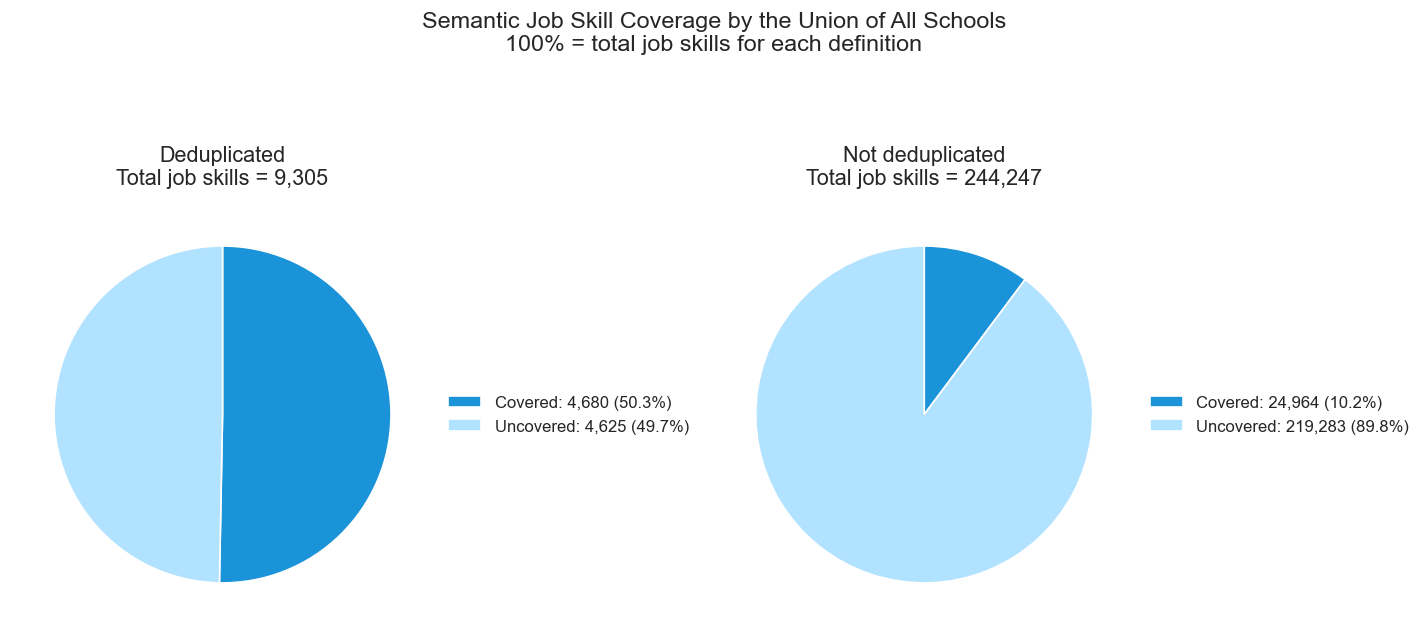

In [19]:
# Create the combined-system pie charts for deduplicated and mention-weighted coverage.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# Draw one pie chart for each coverage definition in the combined all-schools system.
for ax, (_, row) in zip(axes, union_coverage_df.iterrows()):
    sizes = [row["covered_count"], row["uncovered_count"]]
    covered_color = darken_color(ALL_SCHOOLS_COLOR)
    uncovered_color = lighten_color(ALL_SCHOOLS_COLOR)
    ax.pie(
        sizes,
        colors=[covered_color, uncovered_color],
        startangle=90,
        counterclock=False,
        wedgeprops={"edgecolor": "white", "linewidth": 1},
        textprops={"fontsize": 10, "fontweight": "bold"},
    )
    ax.legend(
        make_pie_legend_labels(sizes, row["total_count"]),
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=False,
    )
    ax.set_title(
        f"{row['metric']}\nTotal job skills = {row['total_count']:,}",
        fontsize=13,
        pad=12,
    )

# Add the figure title and render the combined-system coverage chart.
fig.suptitle(
    "Semantic Job Skill Coverage by the Union of All Schools\n100% = total job skills for each definition",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()


## Per-school coverage

This cell compares baseline semantic coverage across NUS, SMU, and SUTD using the same job-skill benchmark.


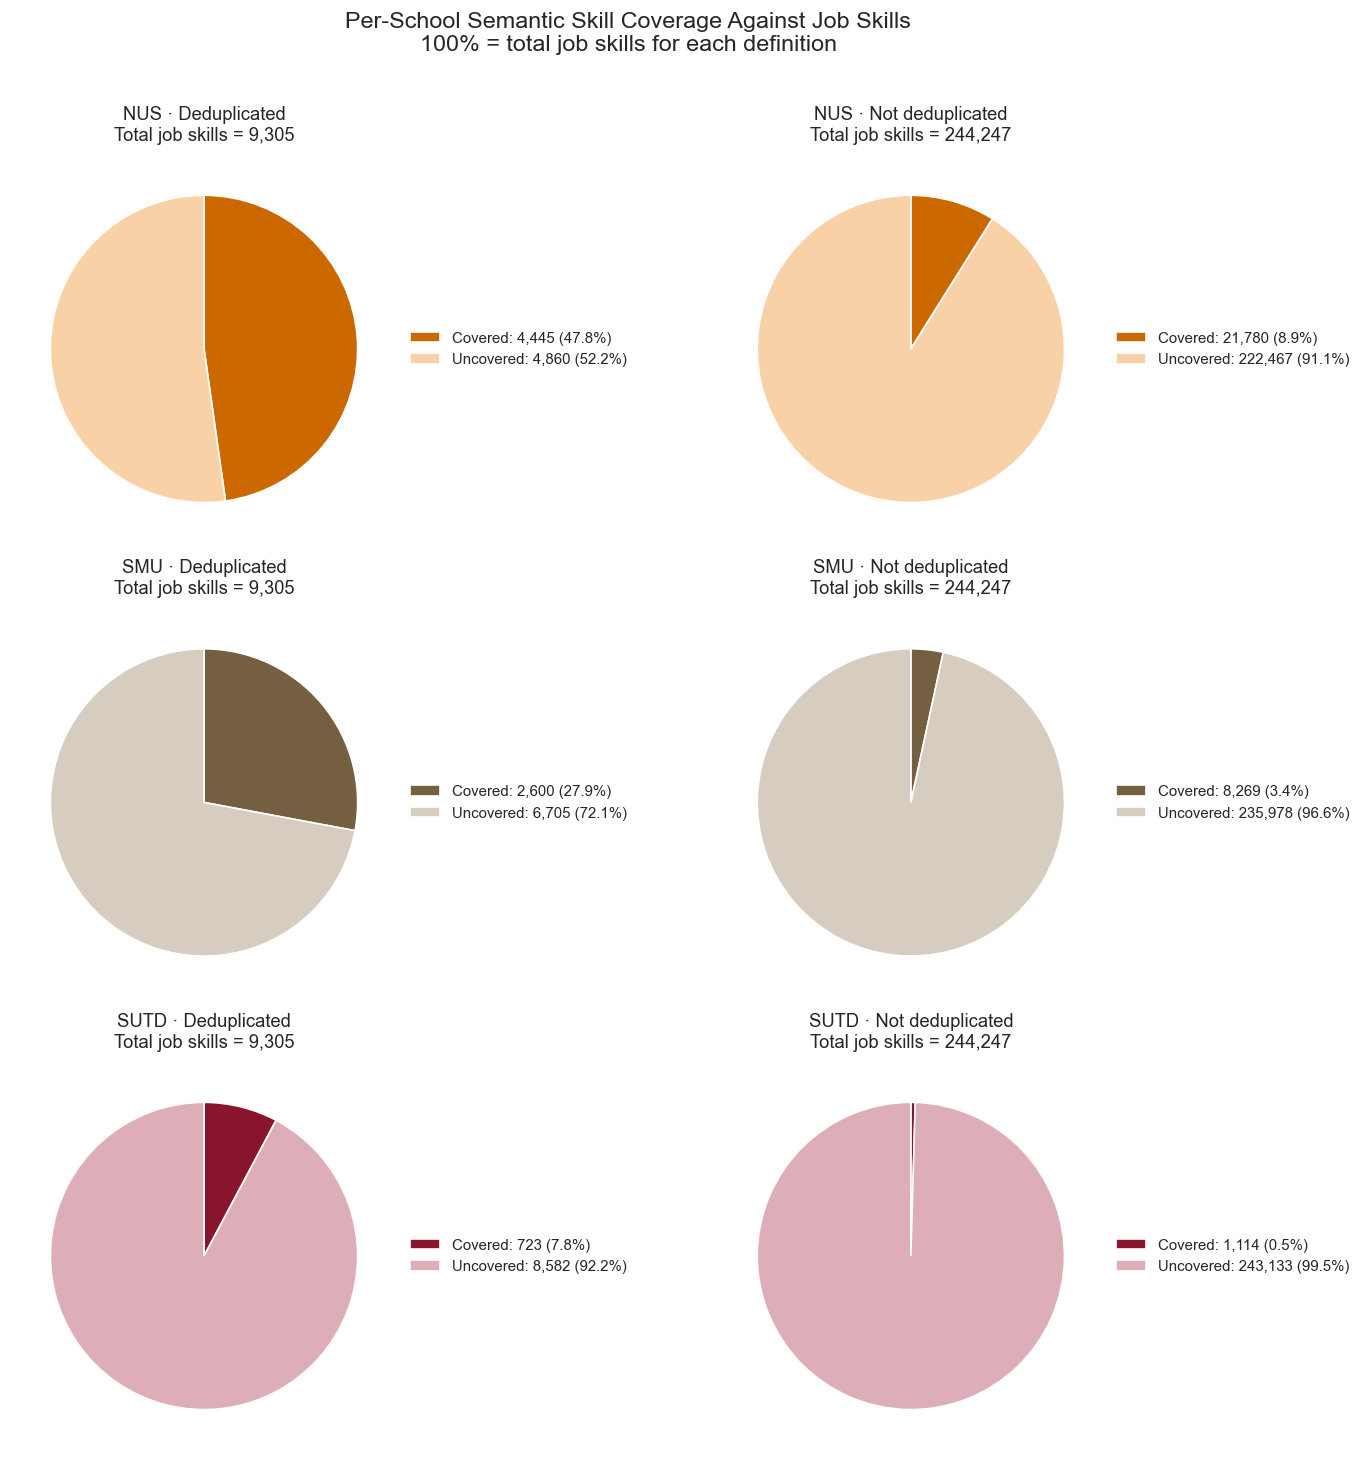

In [20]:
# Create the per-school coverage pie charts for deduplicated and mention-weighted coverage.
metrics = ["Deduplicated", "Not deduplicated"]
fig, axes = plt.subplots(len(SCHOOL_ORDER), len(metrics), figsize=(13, 12))

# Draw one pie chart for each school-metric combination.
for row_idx, school in enumerate(SCHOOL_ORDER):
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        row = school_coverage_df[
            (school_coverage_df["school"] == school) & (school_coverage_df["metric"] == metric)
        ].iloc[0]
        sizes = [row["covered_count"], row["uncovered_count"]]
        base_color = SCHOOL_COLORS[school]
        covered_color = darken_color(base_color)
        uncovered_color = lighten_color(base_color)
        ax.pie(
            sizes,
            colors=[covered_color, uncovered_color],
            startangle=90,
            counterclock=False,
            wedgeprops={"edgecolor": "white", "linewidth": 1},
            textprops={"fontsize": 9, "fontweight": "bold"},
        )
        ax.legend(
            make_pie_legend_labels(sizes, row["total_count"]),
            loc="center left",
            bbox_to_anchor=(1.0, 0.5),
            frameon=False,
            fontsize=9,
        )
        ax.set_title(
            f"{school} · {metric}\nTotal job skills = {row['total_count']:,}",
            fontsize=11,
            pad=10,
        )

# Add the figure title and render the per-school coverage charts.
fig.suptitle(
    "Per-School Semantic Skill Coverage Against Job Skills\n100% = total job skills for each definition",
    fontsize=14,
    y=1.01,
)
plt.tight_layout()
plt.show()


## Job-level coverage

These cells show how evenly coverage is distributed across individual jobs for the combined system and each school.


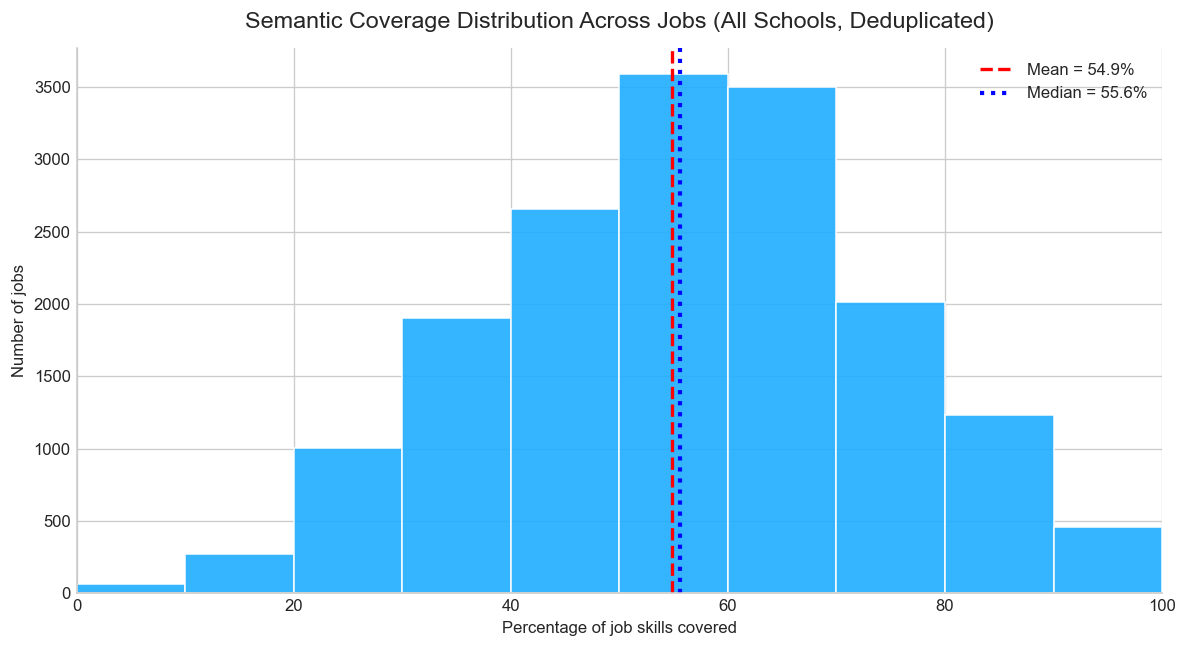

In [21]:
# Compute the mean and median job-level coverage for the combined all-schools system.
mean_pct = union_job_coverage_df["coverage_pct"].mean()
median_pct = union_job_coverage_df["coverage_pct"].median()

# Plot the distribution of deduplicated job-level coverage across all jobs.
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(
    union_job_coverage_df["coverage_pct"],
    bins=10,
    color=ALL_SCHOOLS_COLOR,
    edgecolor="white",
    alpha=0.9,
)
ax.axvline(mean_pct, color=MEAN_LINE_COLOR, linestyle="--", linewidth=2, label=f"Mean = {mean_pct:.1f}%")
ax.axvline(median_pct, color=MEDIAN_LINE_COLOR, linestyle=":", linewidth=2.5, label=f"Median = {median_pct:.1f}%")
ax.set_title("Semantic Coverage Distribution Across Jobs (All Schools, Deduplicated)", fontsize=14, pad=12)
ax.set_xlabel("Percentage of job skills covered")
ax.set_ylabel("Number of jobs")
ax.set_xlim(0, 100)
ax.legend(frameon=False)
hide_top_right(ax)

# Render the combined-system job-level coverage chart.
plt.tight_layout()
plt.show()


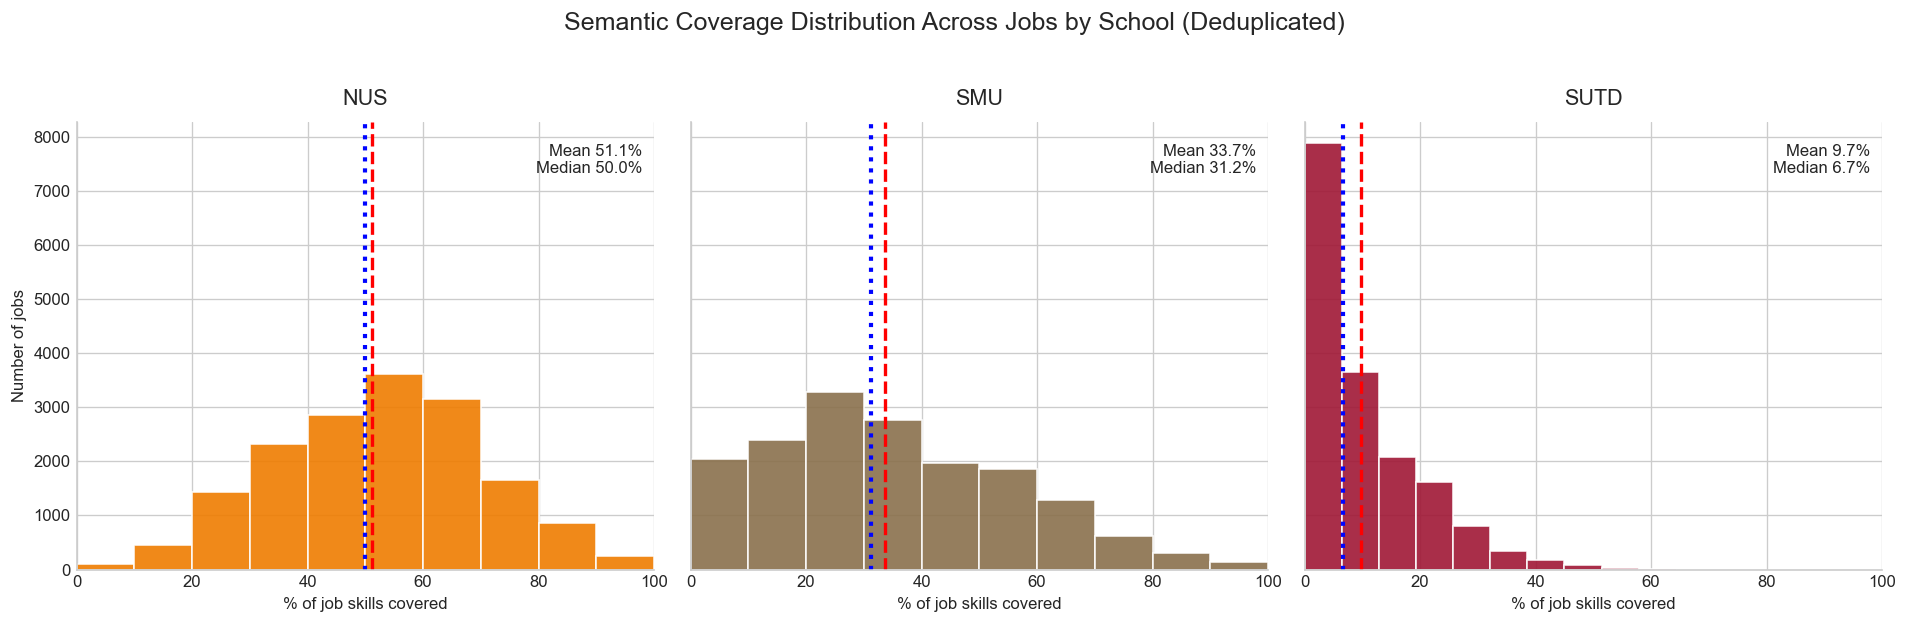

In [22]:
# Create one matched-scale histogram for each school's job-level deduplicated coverage.
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

# Plot the per-school job-level coverage distributions with mean and median reference lines.
for ax, school_name in zip(axes, SCHOOL_ORDER):
    plot_df = per_school_job_coverage[school_name]
    mean_pct = plot_df["coverage_pct"].mean()
    median_pct = plot_df["coverage_pct"].median()
    ax.hist(
        plot_df["coverage_pct"],
        bins=10,
        color=SCHOOL_COLORS[school_name],
        edgecolor="white",
        alpha=0.9,
    )
    ax.axvline(mean_pct, color=MEAN_LINE_COLOR, linestyle="--", linewidth=2)
    ax.axvline(median_pct, color=MEDIAN_LINE_COLOR, linestyle=":", linewidth=2.5)
    ax.set_title(school_name, fontsize=13, pad=10)
    ax.set_xlabel("% of job skills covered")
    ax.set_xlim(0, 100)
    hide_top_right(ax)
    ax.text(
        0.98,
        0.95,
        f"Mean {mean_pct:.1f}%\nMedian {median_pct:.1f}%",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
    )

# Add the shared axis label and render the per-school distribution charts.
axes[0].set_ylabel("Number of jobs")
fig.suptitle("Semantic Coverage Distribution Across Jobs by School (Deduplicated)", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()


## Skill-gap diagnostics

This cell highlights where semantic module supply appears strongest or weakest relative to observed job-skill demand.


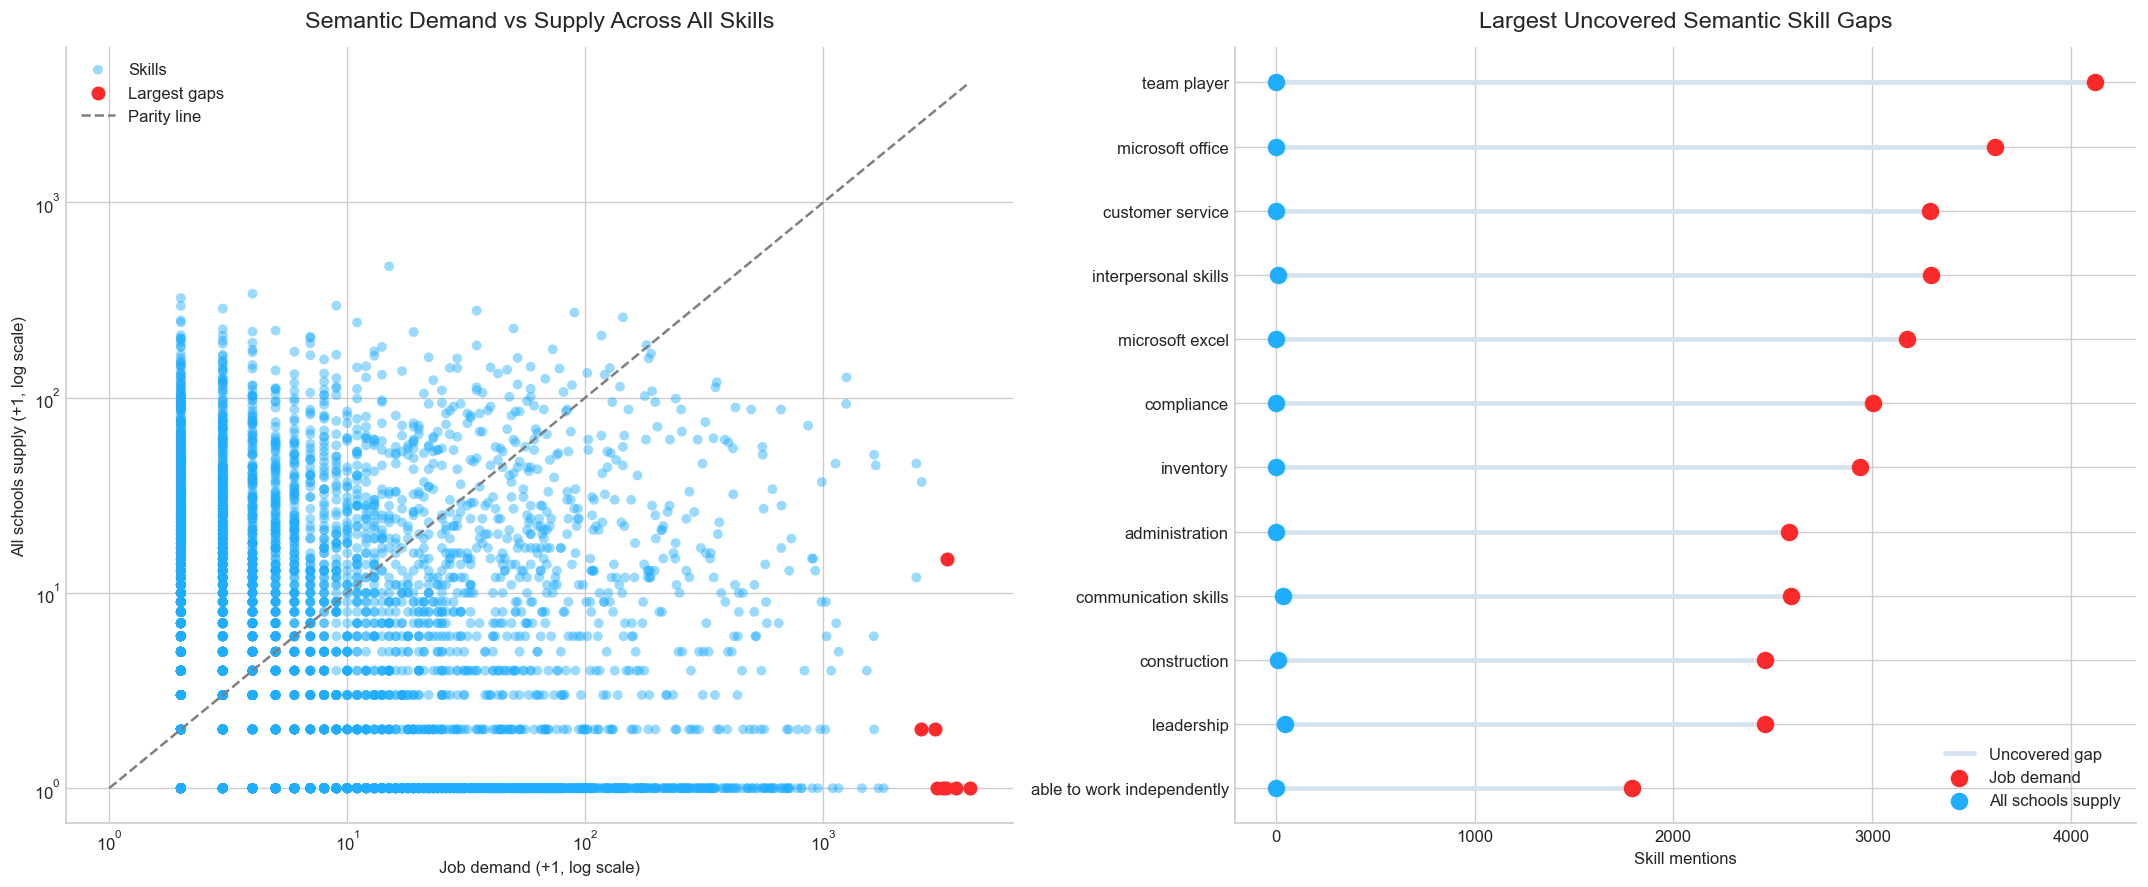

In [23]:
# Build the full skill-level demand-supply table and identify the largest uncovered gaps.
scatter_df = pd.DataFrame([
    {
        "skill": skill,
        "job_demand": demand_count,
        "all_schools_supply": all_schools_counter.get(skill, 0),
    }
    for skill, demand_count in job_skill_counter.items()
])
scatter_df["gap"] = scatter_df["job_demand"] - scatter_df["all_schools_supply"]
label_df = scatter_df.sort_values(["gap", "job_demand"], ascending=[False, False]).head(8)

gap_rows = []
for skill, demand_count in job_skill_counter.items():
    supply_count = all_schools_counter.get(skill, 0)
    gap_rows.append({
        "skill": skill,
        "job_demand": demand_count,
        "all_schools_supply": supply_count,
        "gap": max(demand_count - supply_count, 0),
    })
gap_plot_df = (
    pd.DataFrame(gap_rows)
    .sort_values(["gap", "job_demand", "all_schools_supply"], ascending=[False, False, False])
    .head(TOP_SKILL_COUNT)
    .sort_values("gap", ascending=True)
    .reset_index(drop=True)
)

# Create the demand-supply scatter plot and the largest-gap dumbbell plot side by side.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7.5), gridspec_kw={"width_ratios": [1.05, 1]})

# Plot the full demand-versus-supply relationship on log scales.
ax1.scatter(
    scatter_df["job_demand"] + 1,
    scatter_df["all_schools_supply"] + 1,
    color=ALL_SCHOOLS_COLOR,
    alpha=0.45,
    s=35,
    edgecolors="none",
    label="Skills",
)
ax1.scatter(
    label_df["job_demand"] + 1,
    label_df["all_schools_supply"] + 1,
    color=JOB_DEMAND_COLOR,
    s=55,
    label="Largest gaps",
    zorder=3,
)
max_axis = max(scatter_df["job_demand"].max(), scatter_df["all_schools_supply"].max()) + 1
ax1.plot([1, max_axis], [1, max_axis], linestyle="--", color="#7f7f7f", linewidth=1.5, label="Parity line")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Job demand (+1, log scale)")
ax1.set_ylabel("All schools supply (+1, log scale)")
ax1.set_title("Semantic Demand vs Supply Across All Skills", fontsize=14, pad=12)
ax1.legend(frameon=False, loc="upper left")
hide_top_right(ax1)

# Plot the biggest uncovered gaps using a dumbbell layout.
y_positions = range(len(gap_plot_df))
ax2.hlines(
    y=y_positions,
    xmin=gap_plot_df["all_schools_supply"],
    xmax=gap_plot_df["job_demand"],
    color=GAP_LINE_COLOR,
    linewidth=3,
    label="Uncovered gap",
)
ax2.scatter(
    gap_plot_df["job_demand"],
    y_positions,
    color=JOB_DEMAND_COLOR,
    s=90,
    label="Job demand",
    zorder=3,
)
ax2.scatter(
    gap_plot_df["all_schools_supply"],
    y_positions,
    color=ALL_SCHOOLS_COLOR,
    s=90,
    label="All schools supply",
    zorder=3,
)
ax2.set_yticks(list(y_positions))
ax2.set_yticklabels(gap_plot_df["skill"])
ax2.set_xlabel("Skill mentions")
ax2.set_title("Largest Uncovered Semantic Skill Gaps", fontsize=14, pad=12)
ax2.legend(frameon=False, loc="lower right")
hide_top_right(ax2)

# Render the skill-gap diagnostics.
plt.tight_layout()
plt.show()


## Top-demand skill coverage

This cell compares how much of the highest-demand job skills is covered by the combined system and by each school individually.


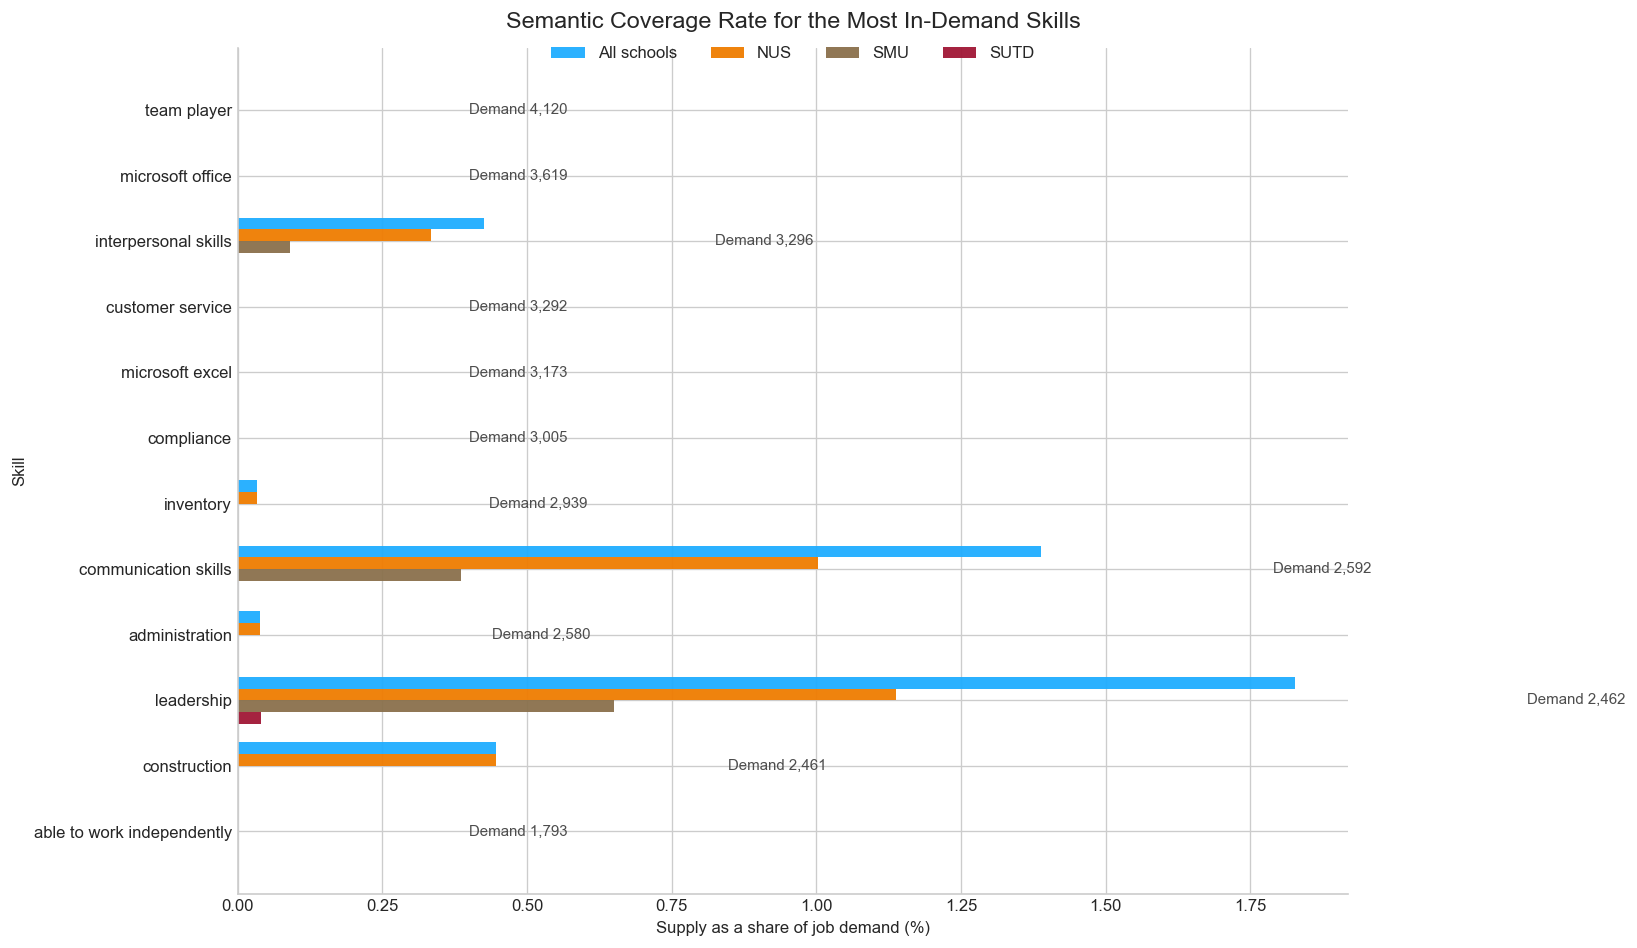

In [24]:
# Build the table for the most in-demand job skills across the combined system and each school.
top_demand_rate_df = (
    pd.DataFrame([
        {
            "skill": skill,
            "job_demand": demand_count,
            "All schools": all_schools_counter.get(skill, 0),
            "NUS": school_skill_counters["NUS"].get(skill, 0),
            "SMU": school_skill_counters["SMU"].get(skill, 0),
            "SUTD": school_skill_counters["SUTD"].get(skill, 0),
        }
        for skill, demand_count in job_skill_counter.items()
    ])
    .sort_values("job_demand", ascending=False)
    .head(TOP_SKILL_COUNT)
    .sort_values("job_demand", ascending=True)
    .reset_index(drop=True)
)

# Convert school-side supply into a percentage of observed job demand for each skill.
for series_name in COMBINED_SERIES:
    top_demand_rate_df[f"{series_name}_pct"] = (
        top_demand_rate_df[series_name] / top_demand_rate_df["job_demand"].replace(0, pd.NA) * 100
    ).fillna(0)

# Create the grouped horizontal bar chart for the most in-demand skills.
y_positions = range(len(top_demand_rate_df))
bar_height = 0.18
offsets = {
    "All schools": 0.27,
    "NUS": 0.09,
    "SMU": -0.09,
    "SUTD": -0.27,
}
fig, ax = plt.subplots(figsize=(14, 8))
for series_name in COMBINED_SERIES:
    ax.barh(
        [y + offsets[series_name] for y in y_positions],
        top_demand_rate_df[f"{series_name}_pct"],
        height=bar_height,
        color=COMBINED_SUPPLY_COLORS[series_name],
        label=series_name,
        alpha=0.95,
    )

# Label each skill with its raw job-demand count.
for i, row in top_demand_rate_df.iterrows():
    ax.text(
        max(row[f"{series_name}_pct"] for series_name in COMBINED_SERIES) + 0.4,
        i,
        f"Demand {int(row['job_demand']):,}",
        va="center",
        fontsize=9,
        color="#4d4d4d",
    )

# Finalize and render the chart.
ax.set_yticks(list(y_positions))
ax.set_yticklabels(top_demand_rate_df["skill"])
ax.set_xlabel("Supply as a share of job demand (%)")
ax.set_ylabel("Skill")
ax.set_title("Semantic Coverage Rate for the Most In-Demand Skills", fontsize=14, pad=12)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.02))
hide_top_right(ax)
plt.tight_layout()
plt.show()


## Topic diagnostics

This cell compares semantic demand and supply across the largest and smallest BERTopic job categories.


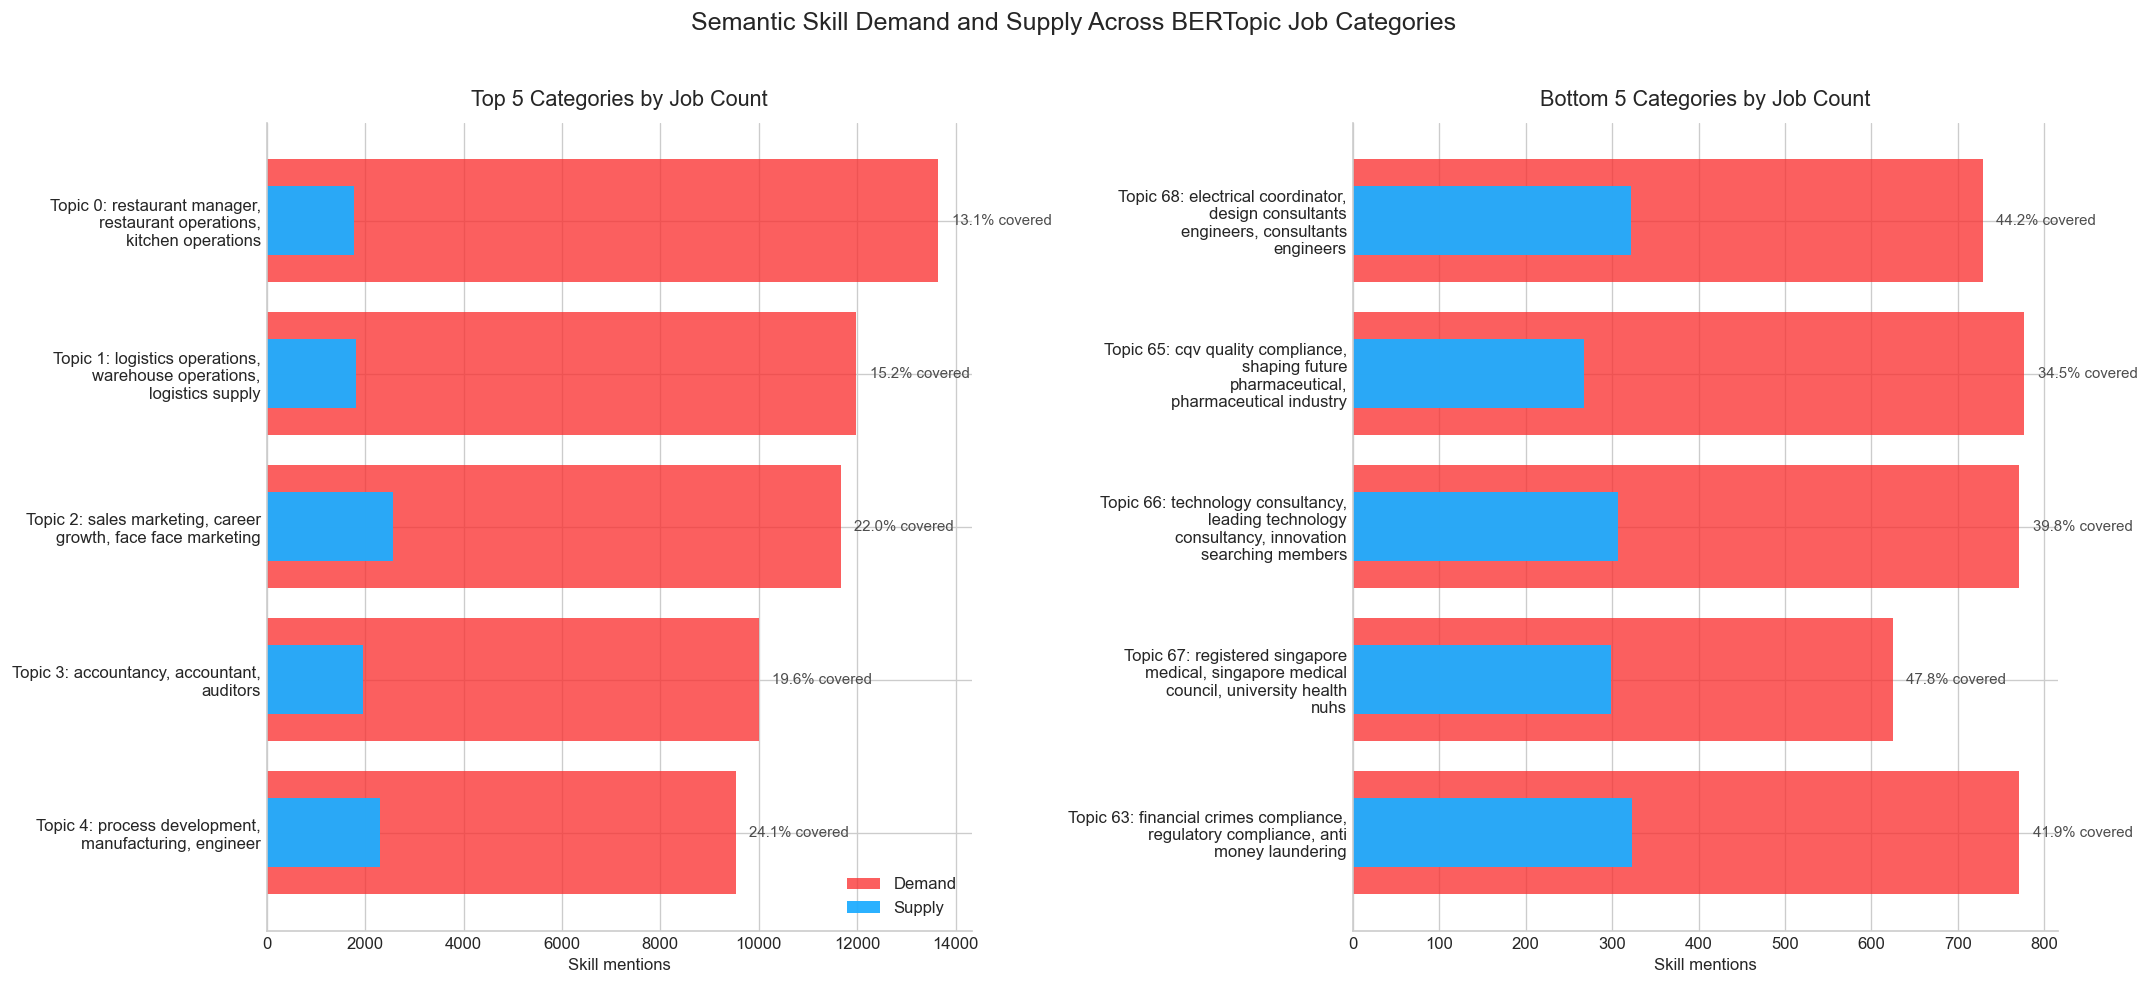

In [25]:
# Load the topic-level job data and drop the BERTopic outlier cluster.
from textwrap import fill

topic_jobs_df = _load_topic_jobs_subset()
topic_jobs_df = topic_jobs_df[topic_jobs_df["topic_id"] != -1].copy()

# Build topic-level demand and supply summaries under the baseline semantic matcher.
topic_rows = []
for (topic_id, topic_label), group in topic_jobs_df.groupby(["topic_id", "topic_label"], dropna=False):
    topic_skill_counter = Counter()
    for skill_array in group["skills"]:
        topic_skill_counter.update(normalize_job_skill_list(skill_array))

    skill_demand = sum(topic_skill_counter.values())
    school_supply = sum(
        min(all_schools_counter.get(skill, 0), demand_count)
        for skill, demand_count in topic_skill_counter.items()
    )
    topic_rows.append({
        "topic_id": topic_id,
        "topic_label": topic_label,
        "job_count": len(group),
        "skill_demand": skill_demand,
        "school_supply": school_supply,
        "coverage_pct": (school_supply / skill_demand * 100) if skill_demand else 0.0,
    })

topic_supply_demand_df = (
    pd.DataFrame(topic_rows)
    .sort_values(["job_count", "topic_id"], ascending=[False, True])
    .reset_index(drop=True)
)
top_categories = topic_supply_demand_df.head(5).copy()
bottom_categories = (
    topic_supply_demand_df.sort_values(["job_count", "topic_id"], ascending=[True, True])
    .head(5)
    .reset_index(drop=True)
)

# Format long topic labels so the bar chart stays readable.
def format_topic_label(row: pd.Series) -> str:
    wrapped = fill(str(row["topic_label"]), width=28)
    return f"Topic {int(row['topic_id'])}: {wrapped}"

# Create side-by-side demand-versus-supply charts for the largest and smallest job topics.
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=False)
plot_specs = [
    (axes[0], top_categories, "Top 5 Categories by Job Count"),
    (axes[1], bottom_categories, "Bottom 5 Categories by Job Count"),
]

# Plot job-skill demand and matched school-side supply for each selected topic.
for ax, plot_df, title in plot_specs:
    labels = [format_topic_label(row) for _, row in plot_df.iterrows()]
    demand_bars = ax.barh(labels, plot_df["skill_demand"], color=JOB_DEMAND_COLOR, alpha=0.75, label="Demand")
    ax.barh(labels, plot_df["school_supply"], color=ALL_SCHOOLS_COLOR, alpha=0.95, height=0.45, label="Supply")
    ax.invert_yaxis()
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Skill mentions")
    hide_top_right(ax)

    x_offset = max(plot_df["skill_demand"].max() * 0.02, 1)
    for bar, (_, row) in zip(demand_bars, plot_df.iterrows()):
        ax.text(
            bar.get_width() + x_offset,
            bar.get_y() + bar.get_height() / 2,
            f"{row['coverage_pct']:.1f}% covered",
            va="center",
            fontsize=9,
            color="#4d4d4d",
        )

# Finalize and render the topic-level chart.
axes[0].legend(frameon=False, loc="lower right")
fig.suptitle("Semantic Skill Demand and Supply Across BERTopic Job Categories", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## Robustness Check 1: Alternative Embedding Models

This cell re-runs the skills matching analysis using different sentence transformer models to assess whether the main findings are robust to the choice of embedding model.


Loading alternative embedding model: all-MiniLM-L6-v2
Encoding job skills with all-MiniLM-L6-v2...


Batches: 100%|██████████████████████████████████| 73/73 [00:01<00:00, 40.04it/s]


Encoding all-school module texts with all-MiniLM-L6-v2...


Batches: 100%|████████████████████████████████| 357/357 [01:07<00:00,  5.27it/s]


Running all-schools semantic matching for all-MiniLM-L6-v2...
Encoding NUS module texts with all-MiniLM-L6-v2...


...

Running SUTD semantic matching for all-mpnet-base-v2...


,model,system,deduplicated_coverage_pct,non_deduplicated_coverage_pct,mean_job_level_deduplicated_coverage_pct,median_job_level_deduplicated_coverage_pct,job_count,unique_job_skill_count,job_skill_mentions
0,all-MiniLM-L6-v2,All schools,42.009672,6.830381,54.396071,55.0,16686,9305,244247
1,all-mpnet-base-v2,All schools,52.595379,11.456845,58.893748,60.0,16686,9305,244247


,model,school,deduplicated_coverage_pct,non_deduplicated_coverage_pct,mean_job_level_deduplicated_coverage_pct,median_job_level_deduplicated_coverage_pct,job_count,unique_job_skill_count,job_skill_mentions
0,all-MiniLM-L6-v2,NUS,38.946803,5.805598,49.782122,50.000000,16686,9305,244247
1,all-MiniLM-L6-v2,SMU,20.558839,2.021314,30.125002,27.272727,16686,9305,244247
2,all-MiniLM-L6-v2,SUTD,4.868350,0.240740,7.782601,6.250000,16686,9305,244247
3,all-mpnet-base-v2,NUS,50.145083,10.053757,56.389124,57.142857,16686,9305,244247
4,all-mpnet-base-v2,SMU,30.381515,3.922259,36.721601,33.333333,16686,9305,244247
5,all-mpnet-base-v2,SUTD,9.134874,0.546168,11.487236,8.333333,16686,9305,244247


,model,system,deduplicated_coverage_pct,non_deduplicated_coverage_pct,mean_job_level_deduplicated_coverage_pct,median_job_level_deduplicated_coverage_pct,job_count,unique_job_skill_count,job_skill_mentions
0,Current notebook baseline (all-mpnet-base-v2),All schools,50.295540,10.220801,54.896481,55.555556,16686,9305,244247
1,all-MiniLM-L6-v2,All schools,42.009672,6.830381,54.396071,55.000000,16686,9305,244247
2,all-mpnet-base-v2,All schools,52.595379,11.456845,58.893748,60.000000,16686,9305,244247


,model,school,deduplicated_coverage_pct,non_deduplicated_coverage_pct,mean_job_level_deduplicated_coverage_pct,median_job_level_deduplicated_coverage_pct,job_count,unique_job_skill_count,job_skill_mentions
0,Current notebook baseline (all-mpnet-base-v2),NUS,47.770016,8.917203,51.133588,50.000000,16686,9305,244247
1,Current notebook baseline (all-mpnet-base-v2),SMU,27.941967,3.385507,33.709256,31.250000,16686,9305,244247
2,Current notebook baseline (all-mpnet-base-v2),SUTD,7.770016,0.456096,9.693488,6.666667,16686,9305,244247
3,all-MiniLM-L6-v2,NUS,38.946803,5.805598,49.782122,50.000000,16686,9305,244247
4,all-MiniLM-L6-v2,SMU,20.558839,2.021314,30.125002,27.272727,16686,9305,244247
5,all-MiniLM-L6-v2,SUTD,4.868350,0.240740,7.782601,6.250000,16686,9305,244247
6,all-mpnet-base-v2,NUS,50.145083,10.053757,56.389124,57.142857,16686,9305,244247
7,all-mpnet-base-v2,SMU,30.381515,3.922259,36.721601,33.333333,16686,9305,244247
8,all-mpnet-base-v2,SUTD,9.134874,0.546168,11.487236,8.333333,16686,9305,244247


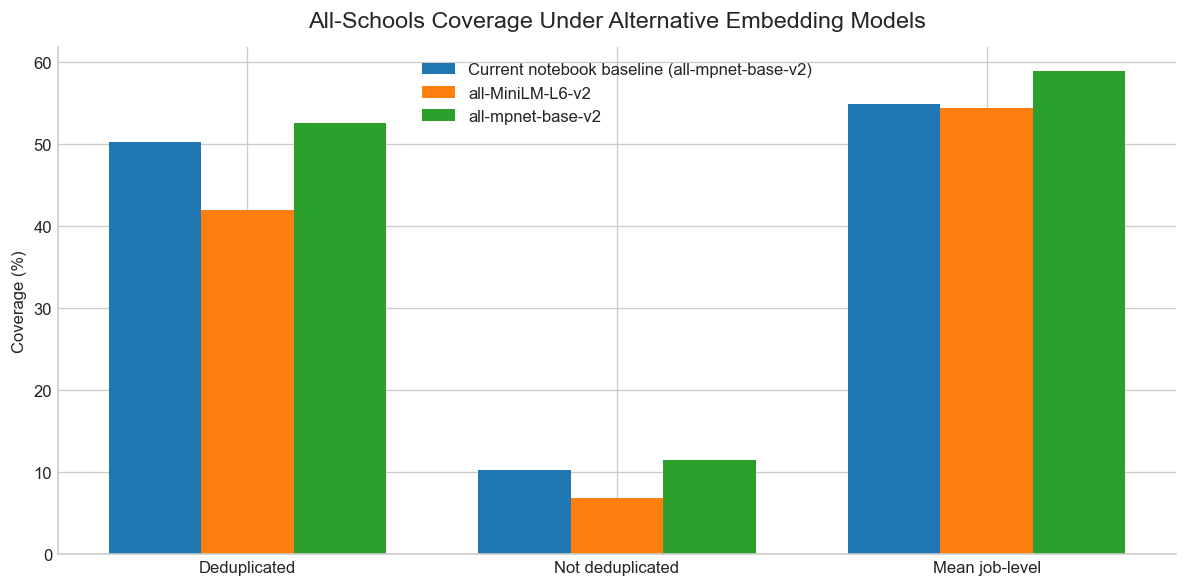

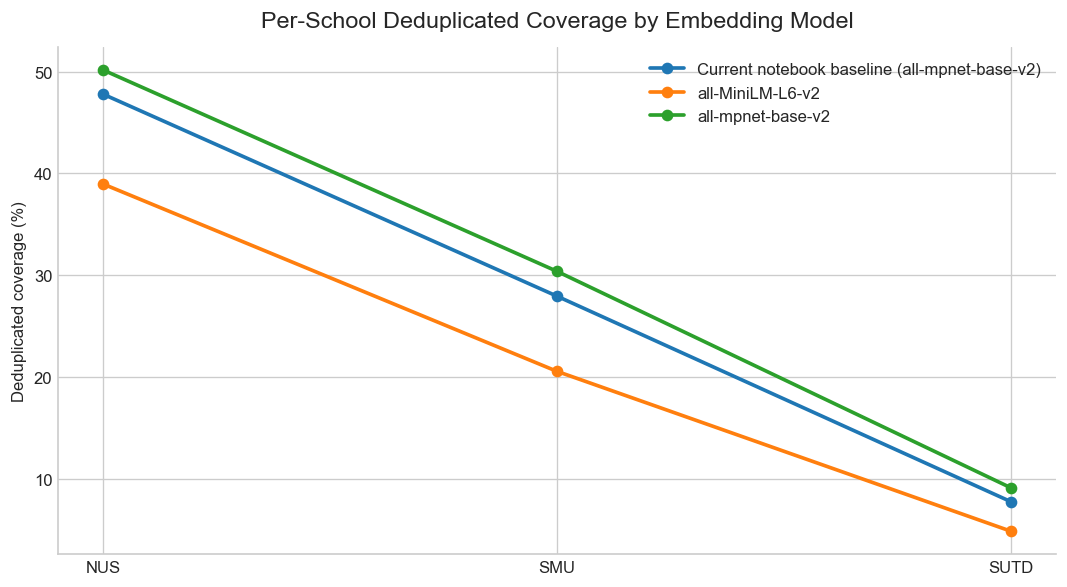

,model,school_ranking_by_deduplicated_coverage
0,Current notebook baseline (all-mpnet-base-v2),NUS > SMU > SUTD
1,all-MiniLM-L6-v2,NUS > SMU > SUTD
2,all-mpnet-base-v2,NUS > SMU > SUTD


Alternative embedding-model summary:
- Current notebook baseline (all-mpnet-base-v2): deduplicated=50.30%, not deduplicated=10.22%, mean job-level=54.90%.
- all-MiniLM-L6-v2: deduplicated=42.01%, not deduplicated=6.83%, mean job-level=54.40%.
- all-mpnet-base-v2: deduplicated=52.60%, not deduplicated=11.46%, mean job-level=58.89%.

Per-school ranking stability:
- Current notebook baseline (all-mpnet-base-v2): NUS > SMU > SUTD
- all-MiniLM-L6-v2: NUS > SMU > SUTD
- all-mpnet-base-v2: NUS > SMU > SUTD

Interpretation guide:
- The exact percentages do not need to match perfectly across models.
- What matters is whether the broad conclusions stay similar.
- In particular, check whether the combined system still outperforms any single school,
  and whether the per-school ranking is broadly stable.


In [26]:
# Alternative embedding-model robustness check
# This reruns the all-schools and per-school matching with fresh embeddings
# from alternative SentenceTransformer models, then compares the headline results.

from pathlib import Path
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ALTERNATIVE_EMBEDDING_MODELS = [
    "all-MiniLM-L6-v2",
    "all-mpnet-base-v2",
]

def resolve_model_path(model_name: str) -> str:
    """
    Prefer a cached local Hugging Face snapshot when available.
    Falls back to the model name otherwise.
    """
    snapshots_dir = (
        Path.home()
        / ".cache"
        / "huggingface"
        / "hub"
        / f"models--sentence-transformers--{model_name.replace('/', '--')}"
        / "snapshots"
    )
    if snapshots_dir.exists():
        snapshots = sorted(path for path in snapshots_dir.iterdir() if path.is_dir())
        if snapshots:
            return str(snapshots[-1])
    return model_name

def load_module_texts_from_file(parquet_path):
    """
    Builds module text from available title/description/code fields.
    This mirrors the logic already used elsewhere in your notebook.
    """
    text_candidates = ["title", "description", "module_name", "code", "module_code"]
    available_columns = [column for column in text_candidates if column in _safe_schema_names(parquet_path)]
    if not available_columns:
        raise KeyError(f"No suitable text columns found in {parquet_path}.")

    text_df = pd.read_parquet(parquet_path, columns=available_columns).fillna("")
    module_texts = []
    for _, row in text_df.iterrows():
        combined = " ".join(
            str(row[column]) for column in available_columns if str(row[column]).strip()
        )
        module_texts.append(normalize_text(combined))
    return module_texts

def encode_and_normalize_texts(model, texts, batch_size=128):
    vectors = model.encode(texts, batch_size=batch_size, show_progress_bar=True)
    vectors = np.asarray(vectors, dtype=np.float32)
    return normalize_rows(vectors)

# Load module text once
all_schools_module_texts = load_module_texts_from_file(ALL_SCHOOLS_FILE)
school_module_texts = {
    school_name: load_module_texts_from_file(school_file)
    for school_name, school_file in SCHOOL_FILES.items()
}

alternative_embedding_rows = []
alternative_embedding_school_rows = []
alternative_embedding_cache = {}

for model_name in ALTERNATIVE_EMBEDDING_MODELS:
    print(f"\nLoading alternative embedding model: {model_name}")
    alt_model = SentenceTransformer(resolve_model_path(model_name))

    print(f"Encoding job skills with {model_name}...")
    alt_job_skill_vectors = encode_and_normalize_texts(alt_model, job_skill_names, batch_size=128)

    print(f"Encoding all-school module texts with {model_name}...")
    alt_all_schools_vectors = encode_and_normalize_texts(
        alt_model,
        all_schools_module_texts,
        batch_size=64,
    )

    print(f"Running all-schools semantic matching for {model_name}...")
    alt_all_counter, alt_all_covered_set, alt_all_best_similarity = summarize_semantic_supply(
        job_skill_names,
        alt_job_skill_vectors,
        alt_all_schools_vectors,
        SIMILARITY_THRESHOLD,
        SKILL_BATCH_SIZE,
    )
    alt_all_metrics = _compute_coverage_metrics(jobs_df, alt_all_counter, alt_all_covered_set)

    alternative_embedding_rows.append({
        "model": model_name,
        "system": "All schools",
        **alt_all_metrics,
    })

    alternative_embedding_cache[model_name] = {
        "job_skill_vectors": alt_job_skill_vectors,
        "all_schools_vectors": alt_all_schools_vectors,
        "all_schools_counter": alt_all_counter,
        "all_schools_covered_set": alt_all_covered_set,
        "all_schools_best_similarity": alt_all_best_similarity,
        "schools": {},
    }

    for school_name in SCHOOL_ORDER:
        print(f"Encoding {school_name} module texts with {model_name}...")
        alt_school_vectors = encode_and_normalize_texts(
            alt_model,
            school_module_texts[school_name],
            batch_size=64,
        )

        print(f"Running {school_name} semantic matching for {model_name}...")
        alt_school_counter, alt_school_covered_set, alt_school_best_similarity = summarize_semantic_supply(
            job_skill_names,
            alt_job_skill_vectors,
            alt_school_vectors,
            SIMILARITY_THRESHOLD,
            SKILL_BATCH_SIZE,
        )
        alt_school_metrics = _compute_coverage_metrics(jobs_df, alt_school_counter, alt_school_covered_set)

        alternative_embedding_school_rows.append({
            "model": model_name,
            "school": school_name,
            **alt_school_metrics,
        })

        alternative_embedding_cache[model_name]["schools"][school_name] = {
            "vectors": alt_school_vectors,
            "counter": alt_school_counter,
            "covered_set": alt_school_covered_set,
            "best_similarity": alt_school_best_similarity,
        }

# Tidy output tables
alternative_embedding_df = pd.DataFrame(alternative_embedding_rows).sort_values(
    ["model", "system"]
).reset_index(drop=True)

alternative_embedding_school_df = pd.DataFrame(alternative_embedding_school_rows).sort_values(
    ["model", "school"]
).reset_index(drop=True)

display(alternative_embedding_df)
display(alternative_embedding_school_df)

# Compare against your current baseline result already in the notebook, if available
baseline_model_label = f"Current notebook baseline ({EMBEDDING_MODEL_NAME})"
baseline_all_row = pd.DataFrame([{
    "model": baseline_model_label,
    "system": "All schools",
    **baseline_metrics,
}])

baseline_school_rows = []
for school_name in SCHOOL_ORDER:
    school_metrics = _compute_coverage_metrics(
        jobs_df,
        school_skill_counters[school_name],
        dedup_school_skill_sets[school_name],
    )
    baseline_school_rows.append({
        "model": baseline_model_label,
        "school": school_name,
        **school_metrics,
    })
baseline_school_df = pd.DataFrame(baseline_school_rows)

embedding_model_comparison_df = pd.concat(
    [baseline_all_row, alternative_embedding_df],
    ignore_index=True,
)

embedding_school_comparison_df = pd.concat(
    [baseline_school_df, alternative_embedding_school_df],
    ignore_index=True,
)

display(embedding_model_comparison_df)
display(embedding_school_comparison_df)

# Plot 1: all-schools comparison across embedding models
metric_specs = [
    ("deduplicated_coverage_pct", "Deduplicated"),
    ("non_deduplicated_coverage_pct", "Not deduplicated"),
    ("mean_job_level_deduplicated_coverage_pct", "Mean job-level"),
]
x_positions = np.arange(len(metric_specs))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for idx, (_, row) in enumerate(embedding_model_comparison_df.iterrows()):
    ax.bar(
        x_positions + (idx - (len(embedding_model_comparison_df) - 1) / 2) * bar_width,
        [row[column] for column, _ in metric_specs],
        width=bar_width,
        label=row["model"],
    )

ax.set_title("All-Schools Coverage Under Alternative Embedding Models", fontsize=14, pad=12)
ax.set_ylabel("Coverage (%)")
ax.set_xticks(x_positions)
ax.set_xticklabels([label for _, label in metric_specs])
ax.legend(frameon=False)
hide_top_right(ax)
plt.tight_layout()
plt.show()

# Plot 2: per-school deduplicated coverage under each model
fig, ax = plt.subplots(figsize=(9, 5))
for model_name, plot_df in embedding_school_comparison_df.groupby("model"):
    plot_df = plot_df.set_index("school").reindex(SCHOOL_ORDER).reset_index()
    ax.plot(
        plot_df["school"],
        plot_df["deduplicated_coverage_pct"],
        marker="o",
        linewidth=2.2,
        label=model_name,
    )

ax.set_title("Per-School Deduplicated Coverage by Embedding Model", fontsize=14, pad=12)
ax.set_ylabel("Deduplicated coverage (%)")
ax.set_xlabel("")
ax.legend(frameon=False)
hide_top_right(ax)
plt.tight_layout()
plt.show()

# Ranking stability summary
school_rank_rows = []
for model_name, plot_df in embedding_school_comparison_df.groupby("model"):
    ordered = tuple(
        plot_df.sort_values(
            ["deduplicated_coverage_pct", "school"],
            ascending=[False, True],
        )["school"]
    )
    school_rank_rows.append({
        "model": model_name,
        "school_ranking_by_deduplicated_coverage": " > ".join(ordered),
    })

embedding_ranking_stability_df = pd.DataFrame(school_rank_rows)
display(embedding_ranking_stability_df)

print("Alternative embedding-model summary:")
for _, row in embedding_model_comparison_df.iterrows():
    print(
        f"- {row['model']}: deduplicated={row['deduplicated_coverage_pct']:.2f}%, "
        f"not deduplicated={row['non_deduplicated_coverage_pct']:.2f}%, "
        f"mean job-level={row['mean_job_level_deduplicated_coverage_pct']:.2f}%."
    )

print("\nPer-school ranking stability:")
for _, row in embedding_ranking_stability_df.iterrows():
    print(f"- {row['model']}: {row['school_ranking_by_deduplicated_coverage']}")

print("\nInterpretation guide:")
print("- The exact percentages do not need to match perfectly across models.")
print("- What matters is whether the broad conclusions stay similar.")
print("- In particular, check whether the combined system still outperforms any single school,")
print("  and whether the per-school ranking is broadly stable.")

## Robustness check 2: threshold sensitivity

This cell tests whether the main findings remain broadly consistent when the similarity threshold is varied around the baseline of 0.55.

,threshold,deduplicated_coverage_pct,non_deduplicated_coverage_pct,mean_job_level_deduplicated_coverage_pct,median_job_level_deduplicated_coverage_pct
0,0.50,63.449758,16.374408,67.878592,70.000000
1,0.55,50.295540,10.220801,54.896481,55.555556
2,0.60,36.034390,5.674174,39.689141,40.000000
3,0.65,22.052660,2.681302,26.742910,25.000000


,threshold,school,deduplicated_coverage_pct,non_deduplicated_coverage_pct,mean_job_level_deduplicated_coverage_pct,median_job_level_deduplicated_coverage_pct
0,0.50,NUS,61.278882,14.572953,65.408394,68.421053
1,0.50,SMU,39.441161,6.057802,46.024896,46.666667
2,0.50,SUTD,14.046212,0.940851,15.209515,11.764706
3,0.55,NUS,47.770016,8.917203,51.133588,50.000000
4,0.55,SMU,27.941967,3.385507,33.709256,31.250000
5,0.55,SUTD,7.770016,0.456096,9.693488,6.666667
6,0.60,NUS,33.584095,4.847552,37.976886,37.500000
7,0.60,SMU,17.581945,1.692549,23.366861,20.000000
8,0.60,SUTD,3.815153,0.198569,6.224488,5.000000
9,0.65,NUS,19.892531,2.250181,25.133942,25.000000


,specification,threshold,deduplicated_coverage_pct,non_deduplicated_coverage_pct,mean_job_level_deduplicated_coverage_pct,median_job_level_deduplicated_coverage_pct
0,Baseline rule (>=0.55),0.55,50.29554,10.220801,54.896481,55.555556
1,Stricter rule (>=0.60),0.60,36.03439,5.674174,39.689141,40.000000


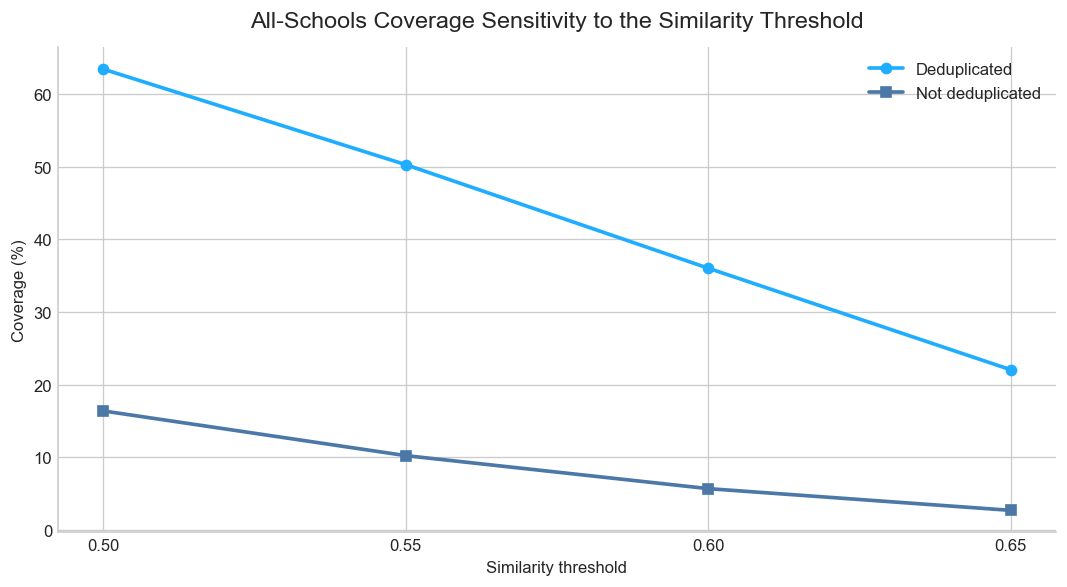

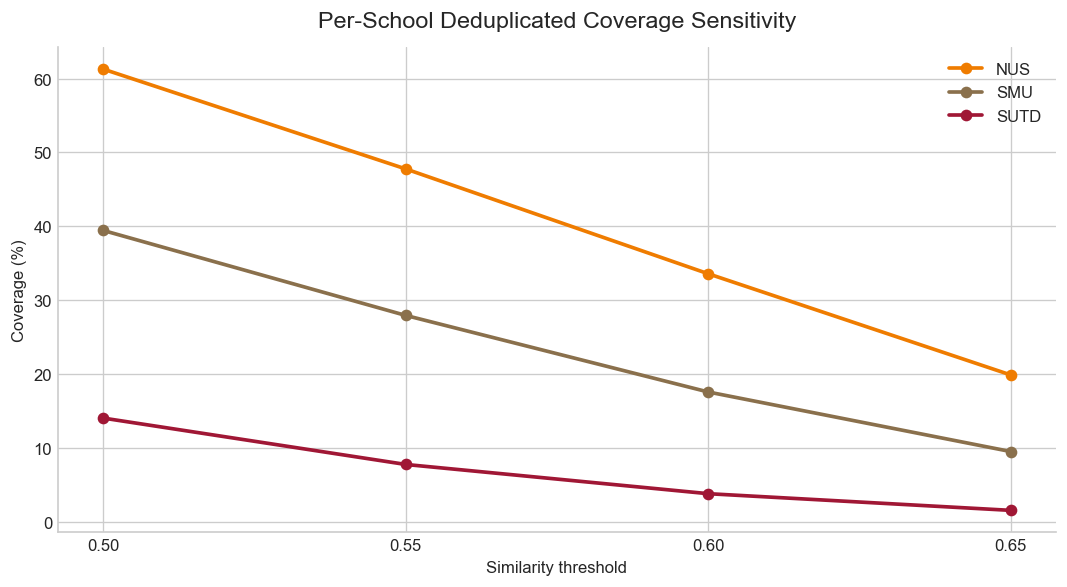

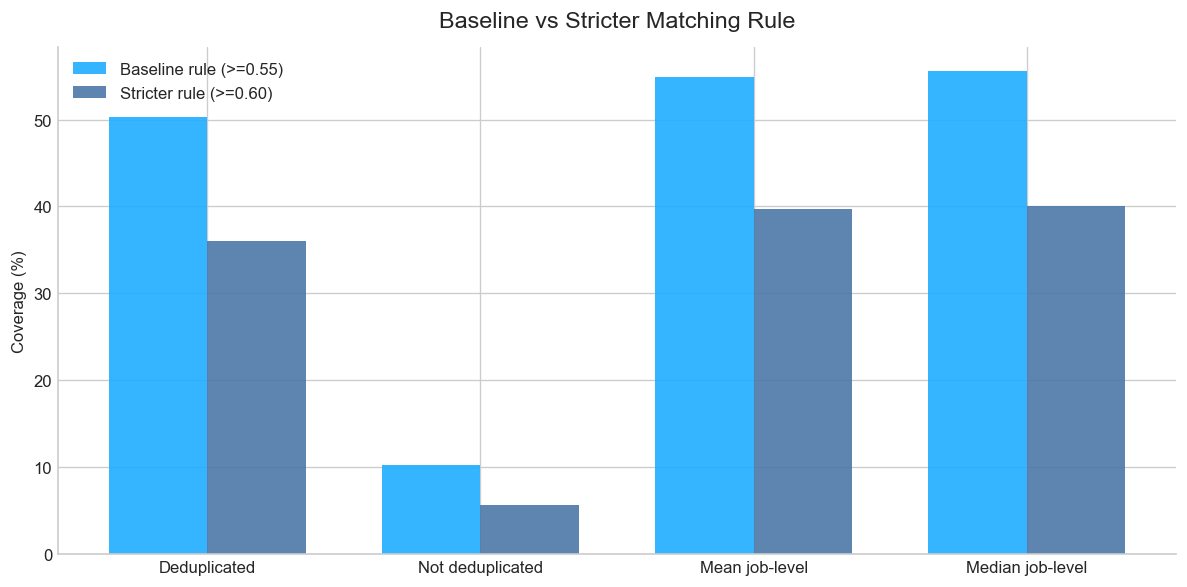

Threshold sensitivity summary:
- The 0.55 baseline is used as a moderate cutoff, and coverage moves from 50.3% at 0.55 to 36.0% at 0.60 under a stricter rule.
- The all-schools deduplicated coverage range across 0.50-0.65 is 22.1% to 63.4%.
- The per-school ranking stays stable across all tested thresholds: ('NUS', 'SMU', 'SUTD').


In [27]:
# Recompute all-schools and per-school coverage across a range of plausible thresholds.
validation_threshold_cache = {}
threshold_rows = []
school_threshold_rows = []

for threshold in VALIDATION_THRESHOLDS:
    all_counter_t, all_covered_set_t, all_best_similarity_t = _run_threshold_supply(all_schools_vectors, threshold)
    all_job_coverage_t = per_job_dedup_coverage(jobs_df, all_covered_set_t)
    validation_threshold_cache[threshold] = {
        "all_schools_counter": all_counter_t,
        "all_schools_covered_set": all_covered_set_t,
        "all_schools_best_similarity": all_best_similarity_t,
        "all_schools_job_coverage_df": all_job_coverage_t.copy(),
        "school_results": {},
    }

    threshold_rows.append({
        "threshold": threshold,
        "deduplicated_coverage_pct": _coverage_pct(
            dedup_covered_count(all_counter_t, job_skill_counter),
            total_unique_job_skills,
        ),
        "non_deduplicated_coverage_pct": _coverage_pct(
            multiset_covered_count(all_counter_t, job_skill_counter),
            total_job_skill_mentions,
        ),
        "mean_job_level_deduplicated_coverage_pct": all_job_coverage_t["coverage_pct"].mean(),
        "median_job_level_deduplicated_coverage_pct": all_job_coverage_t["coverage_pct"].median(),
    })

    for school_name in SCHOOL_ORDER:
        school_counter_t, school_covered_set_t, school_best_similarity_t = _run_threshold_supply(
            school_module_vectors[school_name],
            threshold,
        )
        school_job_coverage_t = per_job_dedup_coverage(jobs_df, school_covered_set_t)
        validation_threshold_cache[threshold]["school_results"][school_name] = {
            "counter": school_counter_t,
            "covered_set": school_covered_set_t,
            "best_similarity": school_best_similarity_t,
            "job_coverage_df": school_job_coverage_t.copy(),
        }
        school_threshold_rows.append({
            "threshold": threshold,
            "school": school_name,
            "deduplicated_coverage_pct": _coverage_pct(
                dedup_covered_count(school_counter_t, job_skill_counter),
                total_unique_job_skills,
            ),
            "non_deduplicated_coverage_pct": _coverage_pct(
                multiset_covered_count(school_counter_t, job_skill_counter),
                total_job_skill_mentions,
            ),
            "mean_job_level_deduplicated_coverage_pct": school_job_coverage_t["coverage_pct"].mean(),
            "median_job_level_deduplicated_coverage_pct": school_job_coverage_t["coverage_pct"].median(),
        })

# Store the threshold sensitivity results in tidy DataFrames for later reference.
threshold_robustness_df = pd.DataFrame(threshold_rows).sort_values("threshold").reset_index(drop=True)
school_threshold_robustness_df = pd.DataFrame(school_threshold_rows).sort_values(["threshold", "school"]).reset_index(drop=True)
spec_comparison_df = (
    threshold_robustness_df[threshold_robustness_df["threshold"].isin([SIMILARITY_THRESHOLD, STRICTER_THRESHOLD])]
    .assign(
        specification=lambda df: df["threshold"].map({
            SIMILARITY_THRESHOLD: f"Baseline rule (>={SIMILARITY_THRESHOLD:.2f})",
            STRICTER_THRESHOLD: f"Stricter rule (>={STRICTER_THRESHOLD:.2f})",
        })
    )
    .loc[:, [
        "specification",
        "threshold",
        "deduplicated_coverage_pct",
        "non_deduplicated_coverage_pct",
        "mean_job_level_deduplicated_coverage_pct",
        "median_job_level_deduplicated_coverage_pct",
    ]]
    .reset_index(drop=True)
)

# Display the threshold sensitivity tables before plotting them.
display(threshold_robustness_df)
display(school_threshold_robustness_df)
display(spec_comparison_df)

# Plot the combined-system sensitivity to the similarity threshold.
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    threshold_robustness_df["threshold"],
    threshold_robustness_df["deduplicated_coverage_pct"],
    marker="o",
    linewidth=2.2,
    color=ALL_SCHOOLS_COLOR,
    label="Deduplicated",
)
ax.plot(
    threshold_robustness_df["threshold"],
    threshold_robustness_df["non_deduplicated_coverage_pct"],
    marker="s",
    linewidth=2.2,
    color="#4c78a8",
    label="Not deduplicated",
)
ax.set_title("All-Schools Coverage Sensitivity to the Similarity Threshold", fontsize=14, pad=12)
ax.set_xlabel("Similarity threshold")
ax.set_ylabel("Coverage (%)")
ax.set_xticks(VALIDATION_THRESHOLDS)
ax.legend(frameon=False)
hide_top_right(ax)
plt.tight_layout()
plt.show()

# Plot the per-school deduplicated coverage curves to check whether rankings stay stable.
fig, ax = plt.subplots(figsize=(9, 5))
for school_name in SCHOOL_ORDER:
    plot_df = school_threshold_robustness_df[school_threshold_robustness_df["school"] == school_name]
    ax.plot(
        plot_df["threshold"],
        plot_df["deduplicated_coverage_pct"],
        marker="o",
        linewidth=2.2,
        color=SCHOOL_COLORS[school_name],
        label=school_name,
    )
ax.set_title("Per-School Deduplicated Coverage Sensitivity", fontsize=14, pad=12)
ax.set_xlabel("Similarity threshold")
ax.set_ylabel("Coverage (%)")
ax.set_xticks(VALIDATION_THRESHOLDS)
ax.legend(frameon=False)
hide_top_right(ax)
plt.tight_layout()
plt.show()

# Plot the baseline and stricter specification side by side for a direct comparison.
metric_labels = [
    ("deduplicated_coverage_pct", "Deduplicated"),
    ("non_deduplicated_coverage_pct", "Not deduplicated"),
    ("mean_job_level_deduplicated_coverage_pct", "Mean job-level"),
    ("median_job_level_deduplicated_coverage_pct", "Median job-level"),
]
x_positions = np.arange(len(metric_labels))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))
for idx, (_, spec_row) in enumerate(spec_comparison_df.iterrows()):
    ax.bar(
        x_positions + (idx - 0.5) * bar_width,
        [spec_row[column] for column, _ in metric_labels],
        width=bar_width,
        color=ALL_SCHOOLS_COLOR if idx == 0 else "#4c78a8",
        alpha=0.9,
        label=spec_row["specification"],
    )
ax.set_title("Baseline vs Stricter Matching Rule", fontsize=14, pad=12)
ax.set_ylabel("Coverage (%)")
ax.set_xticks(x_positions)
ax.set_xticklabels([label for _, label in metric_labels])
ax.legend(frameon=False)
hide_top_right(ax)
plt.tight_layout()
plt.show()

# Summarize whether the headline results look stable around the baseline threshold.
ranking_by_threshold = (
    school_threshold_robustness_df
    .assign(school=pd.Categorical(school_threshold_robustness_df["school"], categories=SCHOOL_ORDER, ordered=True))
    .sort_values(["threshold", "deduplicated_coverage_pct", "school"], ascending=[True, False, True])
    .groupby("threshold")["school"]
    .apply(lambda values: tuple(values.astype(str)))
)
ranking_is_stable = ranking_by_threshold.nunique() == 1
baseline_row = threshold_robustness_df.loc[threshold_robustness_df["threshold"] == SIMILARITY_THRESHOLD].iloc[0]
stricter_row = threshold_robustness_df.loc[threshold_robustness_df["threshold"] == STRICTER_THRESHOLD].iloc[0]

print("Threshold sensitivity summary:")
print(
    f"- The 0.55 baseline is used as a moderate cutoff, and coverage moves from "
    f"{baseline_row['deduplicated_coverage_pct']:.1f}% at 0.55 to "
    f"{stricter_row['deduplicated_coverage_pct']:.1f}% at 0.60 under a stricter rule."
)
print(
    f"- The all-schools deduplicated coverage range across {VALIDATION_THRESHOLDS[0]:.2f}-{VALIDATION_THRESHOLDS[-1]:.2f} "
    f"is {threshold_robustness_df['deduplicated_coverage_pct'].min():.1f}% to "
    f"{threshold_robustness_df['deduplicated_coverage_pct'].max():.1f}%."
)
if ranking_is_stable:
    print(f"- The per-school ranking stays stable across all tested thresholds: {ranking_by_threshold.iloc[0]}.")
else:
    print(f"- The per-school ranking changes across thresholds: {ranking_by_threshold.to_dict()}.")


## Robustness check 3: bootstrap uncertainty

This cell uses bootstrap resampling of jobs to quantify how much the coverage estimates depend on the observed job mix.

,system,metric,point_estimate_pct,bootstrap_mean_pct,ci_lower_pct,ci_upper_pct
0,All schools,Deduplicated coverage,50.295540,50.592965,50.137010,51.106249
1,All schools,Not deduplicated coverage,10.220801,10.045710,9.919021,10.166432
2,All schools,Mean job-level coverage,54.896481,54.887271,54.597128,55.145229
3,NUS,Deduplicated coverage,47.770016,48.083799,47.638706,48.536699
4,SMU,Deduplicated coverage,27.941967,28.198522,27.789400,28.634287
5,SUTD,Deduplicated coverage,7.770016,7.940731,7.704599,8.186325


,ranking,share_of_bootstrap_samples
0,"(NUS, SMU, SUTD)",1.0


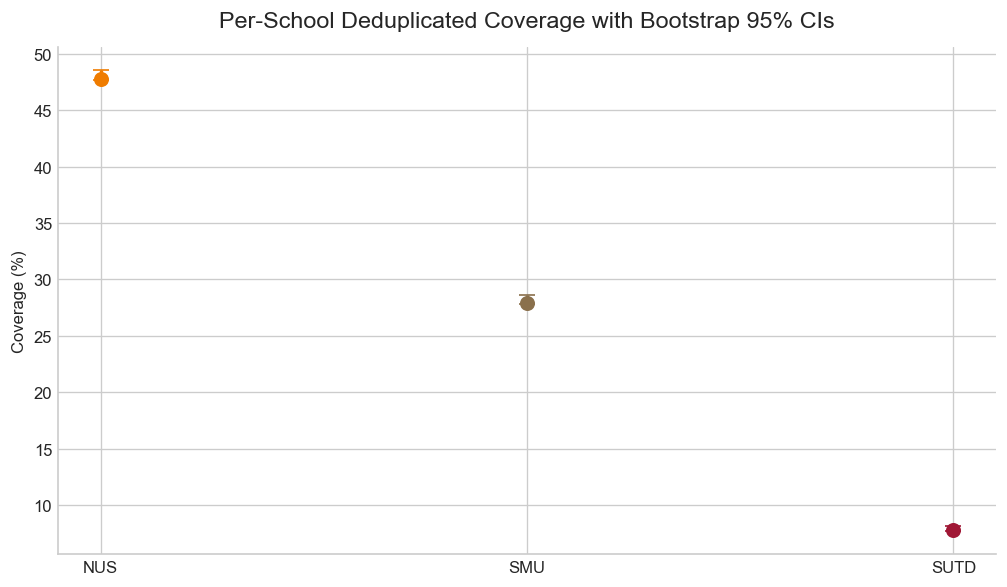

Bootstrap summary:
- The most common per-school ranking is ('NUS', 'SMU', 'SUTD'), appearing in 100.0% of bootstrap samples.
- Narrow confidence intervals imply the estimated coverage rates are less sensitive to the exact sample of jobs.


In [28]:
# Resample jobs with replacement so the coverage estimates can be stress-tested against sample variation.
bootstrap_rng = np.random.default_rng(AUTOMATIC_RANDOM_SEED)
bootstrap_systems = {
    "All schools": (all_schools_counter, dedup_all_schools_skill_set),
    **{
        school_name: (
            school_skill_counters[school_name],
            dedup_school_skill_sets[school_name],
        )
        for school_name in SCHOOL_ORDER
    },
}
bootstrap_rows = []
bootstrap_ranking_rows = []
job_count = len(jobs_df)

for iteration in range(AUTOMATIC_BOOTSTRAP_ITERATIONS):
    sampled_indices = bootstrap_rng.integers(0, job_count, size=job_count)
    sampled_jobs_df = jobs_df.iloc[sampled_indices].reset_index(drop=True)
    school_iteration_rows = []

    for system_name, (supply_counter, covered_set) in bootstrap_systems.items():
        metrics = _compute_coverage_metrics(sampled_jobs_df, supply_counter, covered_set)
        bootstrap_rows.append({
            "iteration": iteration + 1,
            "system": system_name,
            **metrics,
        })
        if system_name in SCHOOL_ORDER:
            school_iteration_rows.append((system_name, metrics["deduplicated_coverage_pct"]))

    ordered_school_ranking = tuple(
        school_name
        for school_name, _ in sorted(
            school_iteration_rows,
            key=lambda item: (-item[1], SCHOOL_ORDER.index(item[0])),
        )
    )
    bootstrap_ranking_rows.append({
        "iteration": iteration + 1,
        "ranking": ordered_school_ranking,
    })

# Summarize the bootstrap draws into confidence intervals for the headline metrics.
bootstrap_distribution_df = pd.DataFrame(bootstrap_rows)
bootstrap_ranking_df = pd.DataFrame(bootstrap_ranking_rows)
bootstrap_summary_rows = []
bootstrap_metric_specs = [
    ("All schools", "deduplicated_coverage_pct", "Deduplicated coverage"),
    ("All schools", "non_deduplicated_coverage_pct", "Not deduplicated coverage"),
    ("All schools", "mean_job_level_deduplicated_coverage_pct", "Mean job-level coverage"),
    ("NUS", "deduplicated_coverage_pct", "Deduplicated coverage"),
    ("SMU", "deduplicated_coverage_pct", "Deduplicated coverage"),
    ("SUTD", "deduplicated_coverage_pct", "Deduplicated coverage"),
]

for system_name, metric_column, metric_label in bootstrap_metric_specs:
    sample_values = bootstrap_distribution_df.loc[
        bootstrap_distribution_df["system"] == system_name,
        metric_column,
    ]
    point_estimate = (
        baseline_metrics[metric_column]
        if system_name == "All schools"
        else _compute_coverage_metrics(
            jobs_df,
            bootstrap_systems[system_name][0],
            bootstrap_systems[system_name][1],
        )[metric_column]
    )
    bootstrap_summary_rows.append({
        "system": system_name,
        "metric": metric_label,
        "point_estimate_pct": point_estimate,
        "bootstrap_mean_pct": sample_values.mean(),
        "ci_lower_pct": sample_values.quantile(0.025),
        "ci_upper_pct": sample_values.quantile(0.975),
    })

bootstrap_coverage_df = pd.DataFrame(bootstrap_summary_rows)
bootstrap_school_rank_stability_df = (
    bootstrap_ranking_df["ranking"]
    .value_counts(normalize=True)
    .rename_axis("ranking")
    .reset_index(name="share_of_bootstrap_samples")
)

# Display the bootstrap summary tables before plotting the school intervals.
display(bootstrap_coverage_df)
display(bootstrap_school_rank_stability_df)

# Plot 95% bootstrap confidence intervals for per-school deduplicated coverage.
school_bootstrap_plot_df = bootstrap_coverage_df[
    (bootstrap_coverage_df["system"].isin(SCHOOL_ORDER))
    & (bootstrap_coverage_df["metric"] == "Deduplicated coverage")
].copy()
fig, ax = plt.subplots(figsize=(8.5, 5))
for _, row in school_bootstrap_plot_df.iterrows():
    ax.errorbar(
        row["system"],
        row["point_estimate_pct"],
        yerr=[
            [row["point_estimate_pct"] - row["ci_lower_pct"]],
            [row["ci_upper_pct"] - row["point_estimate_pct"]],
        ],
        fmt="o",
        color=SCHOOL_COLORS[row["system"]],
        markersize=8,
        capsize=5,
        linewidth=2,
    )
ax.set_title("Per-School Deduplicated Coverage with Bootstrap 95% CIs", fontsize=14, pad=12)
ax.set_ylabel("Coverage (%)")
hide_top_right(ax)
plt.tight_layout()
plt.show()

# Summarize how stable the school ranking looks across bootstrap samples.
most_common_bootstrap_ranking = bootstrap_school_rank_stability_df.iloc[0]
print("Bootstrap summary:")
print(
    f"- The most common per-school ranking is {most_common_bootstrap_ranking['ranking']}, "
    f"appearing in {most_common_bootstrap_ranking['share_of_bootstrap_samples'] * 100:.1f}% of bootstrap samples."
)
print("- Narrow confidence intervals imply the estimated coverage rates are less sensitive to the exact sample of jobs.")


## Validation: lexical baseline comparison

This cell checks whether semantic matching captures meaningful relationships beyond simple exact phrase overlap between job skills and module text.

,method,deduplicated_coverage_pct,non_deduplicated_coverage_pct,mean_job_level_deduplicated_coverage_pct
0,Semantic similarity,50.295540,10.220801,54.896481
1,Lexical exact phrase,38.893068,14.932425,74.242754


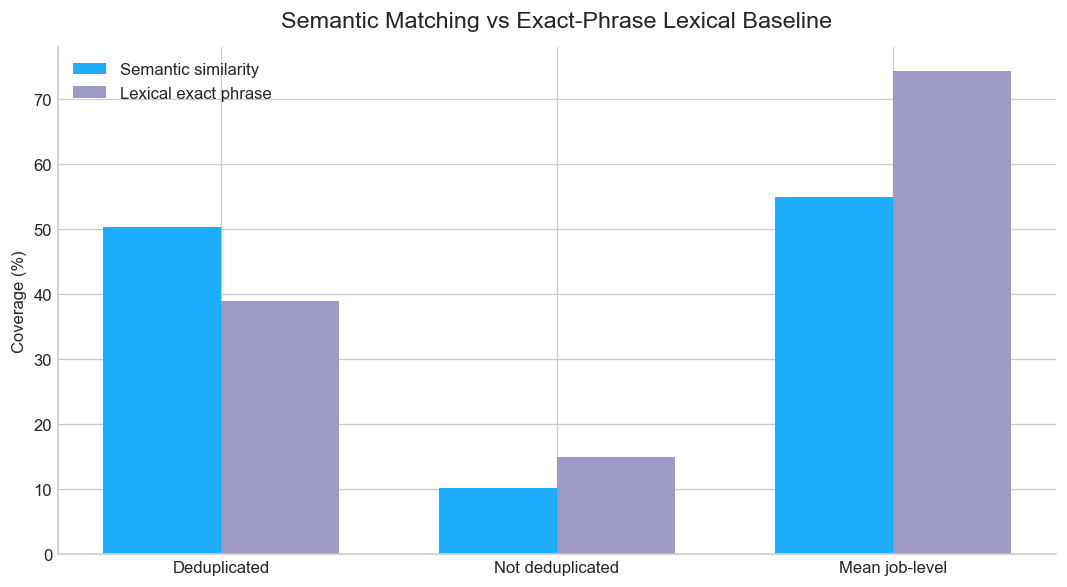

Lexical baseline validation summary:
- Semantic matching changes deduplicated coverage by +11.4 percentage points relative to exact phrase matching.
- A clear semantic uplift suggests the results are not driven only by surface keyword overlap.


In [29]:
# Load module titles and descriptions so semantic matching can be compared against a simple lexical rule.
all_school_module_texts = _load_all_school_module_texts()
lexical_baseline_counter, lexical_baseline_covered_set, lexical_baseline_skill_df = _build_lexical_supply(
    all_school_module_texts,
    job_skill_names,
)
lexical_baseline_metrics = _compute_coverage_metrics(
    jobs_df,
    lexical_baseline_counter,
    lexical_baseline_covered_set,
)

# Store the semantic-versus-lexical comparison in a tidy DataFrame.
lexical_baseline_comparison_df = pd.DataFrame([
    {
        "method": "Semantic similarity",
        "deduplicated_coverage_pct": baseline_metrics["deduplicated_coverage_pct"],
        "non_deduplicated_coverage_pct": baseline_metrics["non_deduplicated_coverage_pct"],
        "mean_job_level_deduplicated_coverage_pct": baseline_metrics["mean_job_level_deduplicated_coverage_pct"],
    },
    {
        "method": "Lexical exact phrase",
        "deduplicated_coverage_pct": lexical_baseline_metrics["deduplicated_coverage_pct"],
        "non_deduplicated_coverage_pct": lexical_baseline_metrics["non_deduplicated_coverage_pct"],
        "mean_job_level_deduplicated_coverage_pct": lexical_baseline_metrics["mean_job_level_deduplicated_coverage_pct"],
    },
])

# Display the validation table before plotting the method comparison.
display(lexical_baseline_comparison_df)

# Plot semantic matching against the lexical exact-phrase baseline.
lexical_metric_specs = [
    ("deduplicated_coverage_pct", "Deduplicated"),
    ("non_deduplicated_coverage_pct", "Not deduplicated"),
    ("mean_job_level_deduplicated_coverage_pct", "Mean job-level"),
]
x_positions = np.arange(len(lexical_metric_specs))
bar_width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
for idx, (_, row) in enumerate(lexical_baseline_comparison_df.iterrows()):
    ax.bar(
        x_positions + (idx - 0.5) * bar_width,
        [row[column] for column, _ in lexical_metric_specs],
        width=bar_width,
        color=ALL_SCHOOLS_COLOR if row["method"] == "Semantic similarity" else "#9e9ac8",
        label=row["method"],
    )
ax.set_title("Semantic Matching vs Exact-Phrase Lexical Baseline", fontsize=14, pad=12)
ax.set_ylabel("Coverage (%)")
ax.set_xticks(x_positions)
ax.set_xticklabels([label for _, label in lexical_metric_specs])
ax.legend(frameon=False)
hide_top_right(ax)
plt.tight_layout()
plt.show()

# Summarize whether semantic matching is adding information beyond exact wording overlap.
lexical_gap = (
    lexical_baseline_comparison_df.loc[
        lexical_baseline_comparison_df["method"] == "Semantic similarity",
        "deduplicated_coverage_pct",
    ].iloc[0]
    - lexical_baseline_comparison_df.loc[
        lexical_baseline_comparison_df["method"] == "Lexical exact phrase",
        "deduplicated_coverage_pct",
    ].iloc[0]
)
print("Lexical baseline validation summary:")
print(
    f"- Semantic matching changes deduplicated coverage by {lexical_gap:+.1f} percentage points "
    f"relative to exact phrase matching."
)
print("- A clear semantic uplift suggests the results are not driven only by surface keyword overlap.")


## Summary

This cell prints a compact interpretation of the modelling choices, three robustness checks, and the extra validation step.


In [30]:
# Pull the key rows needed for a compact notebook summary.
threshold_baseline_row = threshold_robustness_df.loc[
    threshold_robustness_df["threshold"] == SIMILARITY_THRESHOLD
].iloc[0]
threshold_stricter_row = threshold_robustness_df.loc[
    threshold_robustness_df["threshold"] == STRICTER_THRESHOLD
].iloc[0]
bootstrap_all_schools_row = bootstrap_coverage_df.loc[
    (bootstrap_coverage_df["system"] == "All schools")
    & (bootstrap_coverage_df["metric"] == "Deduplicated coverage")
].iloc[0]
lexical_semantic_row = lexical_baseline_comparison_df.loc[
    lexical_baseline_comparison_df["method"] == "Semantic similarity"
].iloc[0]
lexical_exact_row = lexical_baseline_comparison_df.loc[
    lexical_baseline_comparison_df["method"] == "Lexical exact phrase"
].iloc[0]

# Print concise bullet-style findings that connect the method choices to the three robustness checks and the extra validation step.
print("Summary of model choices, robustness checks, and validation:")
print(
    f"- MPNet was chosen because it is a strong sentence embedding model for semantic similarity, "
    f"which is important when modules and job skills use paraphrased wording."
)
print(
    f"- 0.55 was chosen as a moderate baseline threshold, and the threshold check shows "
    f"{threshold_baseline_row['deduplicated_coverage_pct']:.1f}% deduplicated coverage at 0.55 "
    f"versus {threshold_stricter_row['deduplicated_coverage_pct']:.1f}% at 0.60."
)
print(
    f"- Bootstrap resampling gives a 95% confidence interval of "
    f"{bootstrap_all_schools_row['ci_lower_pct']:.1f}% to {bootstrap_all_schools_row['ci_upper_pct']:.1f}% "
    f"for all-schools deduplicated coverage."
)
print(
    f"- The lexical validation check gives {lexical_semantic_row['deduplicated_coverage_pct']:.1f}% "
    f"deduplicated coverage for semantic matching versus "
    f"{lexical_exact_row['deduplicated_coverage_pct']:.1f}% for exact phrase matching."
)


Summary of model choices, robustness checks, and validation:
- MPNet was chosen because it is a strong sentence embedding model for semantic similarity, which is important when modules and job skills use paraphrased wording.
- 0.55 was chosen as a moderate baseline threshold, and the threshold check shows 50.3% deduplicated coverage at 0.55 versus 36.0% at 0.60.
- Bootstrap resampling gives a 95% confidence interval of 50.1% to 51.1% for all-schools deduplicated coverage.
- The lexical validation check gives 50.3% deduplicated coverage for semantic matching versus 38.9% for exact phrase matching.
